# EN.580.447 HW3 - Lillian Lam
## March 6, 2026

## Table of Contents
1. [Question 1: Manual Annotation vs. BB-KNN vs. SCN](#question-1)
    - 1.1 [manual annotations](#manual)
    - 1.2 [BB-KNN](#bbknn)
    - 1.3 [SingleCellNet](#scn)
    - 1.4 [Results](#1result)
    
2. [Question 2: Cell-Typing Method Should or Should Not Handle Hybrids](#question-2)

3. [Question 3:  Performance On Hybrids Populations](#question-3)
    - 3.1 [Hybrid Generation](#hybrid)
    - 3.2 [manual annotations](#manual3)
    - 3.3 [BB-KNN](#bbknn3)
    - 3.4 [SingleCellNet](#scn3)
    - 3.5 [Results](#3result)

4. [Question 4: Transplantation Effect On Engineered Pancreatic-like Cells](#question-4)
    - 4.1 [Cell Type Classification of Query Data](#scn4)
    - 4.2 [Changes in Cell Type Proportions](#prop)
    - 4.3 [Changes in Classification Uncertainty](#uncert)
    - 4.4 [Differential Expression Analysis by Cell Type](#dge)
    - 4.5 [Pathway Enrichment Analysis](#enrich)
    - 4.6 [Shared Dysregulated Genes Across Cell Types](#dysre)
    - 4.7 [Results](#4result)


5. [Extra Credit: Hybrid Identity Score ](#question-5)

---
**Acknowledgment:** Much of the code was taken from [Professor Patrick Cahan's scBasics notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/scBasics.ipynb) and

[Professor Patrick Cahan's cell typing integration notebook](https://github.com/compscbio/cscb2026/blob/gh-pages/notebooks/cell_typing_integration.ipynb).


<a id='question-1'></a>
# 1. How do manual annotation, classification, and integration compare in terms of accurately and sensitively predicting cell type identity?

In [144]:
#required install in google colab
import sys
if 'google.colab' in sys.modules:
    print("Colab detected — installing required packages...")
    !pip install -q scanpy==1.10.3 anndata==0.11.1 bbknn==1.6.0 pySingleCellNet==0.1.3 leidenalg==0.10.2 igraph==0.11.8
else:
    print("Local environment detected — skipping install.")

Colab detected — installing required packages...


In [2]:
#required packages
import scanpy as sc
import random
from scipy.sparse import issparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.sparse import csr_matrix
import seaborn as sns
import igraph as ig
import bbknn
import anndata as ad
import pySingleCellNet as cn
from sklearn.metrics import classification_report, f1_score, accuracy_score
import gseapy as gp
from scipy.stats import chi2_contingency
from collections import Counter
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/usr

In [3]:
training = sc.read_h5ad('/content/adTrain_n110_CSCB_HW3.h5ad')
validation=sc.read_h5ad('/content/adValidation_n300_CSCB_HW3.h5ad')
query=sc.read_h5ad('/content/adQuery_n2000_CSCB_HW3.h5ad')

<a id='manual'></a>
## 1.1 Manual Annotations

## scRNA Sequencing Pipeline Function
I made the ```pipeline``` function to process the raw 10x Genomics data through quality control, normalization, clustering, and visualization. The function is designed to test how different parameter choices affect downstream results by allowing each step to be toggled on/off or modified independently. It is the same code from HW2, but using different markers.

### Pipeline Steps (things that can be altered are conditional)
1. Quality Control
    - Mitochondrial gene identification: Flags genes starting with "MT-" as mitochondrial
    - Ribosomal gene identification: Flags genes starting with "RPS" or "RPL" as ribosomal
    - QC metric calculation: Computes n_genes, total_counts, pct_counts_mt, pct_counts_ribo

    - Cell filtering (conditional):
      - Remove cells with high mitochondrial content (> threshold)
      - Remove cells with low gene counts (< min_genes)
      - Remove cells with high UMI counts (> max_counts) to eliminate doublets

    - Gene filtering: Removes genes detected in fewer than 10 cells

2. Normalization (conditional)
    - Library size normalization: Scales each cell to 10,000 total counts
    - Log transformation: Applies log1p transformation to stabilize variance

3. Highly Variable Gene Selection

    Identifies top 2000 genes with highest variance (heteroskedasticity) across cells. These genes are most informative for distinguishing different cell populations, while housekeeping genes that are expressed similarly across all cells contribute little discriminatory power.These genes will be used for downstream dimensionality reduction.

4. Dimensionality Reduction
    - PCA: Performs principal component analysis on highly variable genes
      - Many genes are correlated in their expression patterns, so there is redundancy in the data.
     - Allows us to capture the variance in the data, instead of the whole genome, making it computationally less exhausting

    - kNN graph (conditional):
      - If use_pcs=True: Uses first n_pcs principal components
      - If use_pcs=False: Uses full HVG expression matrix
      - creates an adjacency matrix by finding, for each cell, the k cells that are closest to it.
      - encodes the local structure of the data, which becomes the backbone of both UMAP and Leiden clustering.

5. Clustering and Visualization
    - UMAP: 2D visualization of cell relationships
    - Leiden clustering: Resolution: 0.5 for more finer clusers (to identify subtypes)

    

In [4]:
def pipeline(adata_raw, filter_mt=True, mt_threshold=20, filter_counts=True,
             max_counts=30000,filter_genes=True, min_genes=500, normalize=True,
             use_pcs=True, n_pcs=10, n_neighbors=20, leiden_resolution=0.5, silent=False, figure_size=(10,5)):


    np.random.seed(0)
    random.seed(0)


    #new copy each time
    adata = adata_raw.copy()

    # QUALITY CONTROL

    #mitochondrial genes
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    # ribosomal genes
    ribo_prefix = ('RPS', 'RPL')
    adata.var['ribo'] = adata.var_names.str.startswith(ribo_prefix)

    #calculate QC metrics to filter out mitocondrial data
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'], percent_top=None, log1p=False, inplace=True)

    #filter cells based on parameters
    if filter_mt:
        adata = adata[adata.obs['pct_counts_mt'] < mt_threshold, :].copy()
    if filter_genes:
        sc.pp.filter_cells(adata, min_genes=min_genes)
    if filter_counts:
        sc.pp.filter_cells(adata, max_counts=max_counts)

    sc.pp.filter_genes(adata, min_cells=10)
    adata.var_names_make_unique()

    #NORMALIZATION

    if normalize:
        #proportion of reads for a gene relative to total library size
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        #store log-normalized data in a new layer
        adata.layers['lognorm'] = adata.X.copy()

    #IDENTIFY HIGHLY VARIABLE GENES

    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='cell_ranger')

    #DIMENSIONAL REDUCTION & CLUSTERING

    sc.tl.pca(adata, mask_var='highly_variable')

    #kNN graph with or without pcs
    if use_pcs:
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=n_pcs, random_state=0)
    else:
        #use the full expression matrix (highly variable genes only)
        adata_hvg = adata[:, adata.var['highly_variable']].copy()
        sc.pp.neighbors(adata, n_neighbors=n_neighbors, use_rep='X', random_state=0)

    #UMAP and Leiden clustering
    sc.tl.umap(adata, random_state=0)
    sc.tl.leiden(adata, resolution=leiden_resolution, flavor='igraph', n_iterations=2, random_state=0, key_added='leiden_cluster')

    #marker gene dictionary from homework 1
    marker_genes ={'Acinar': ['PRSS2', 'REG1A'],
                  'Ductal': ['MMP7', 'KRT19'],
                  'Alpha': ['GCG', 'TTR', 'HIGD1A'],
                  'Beta': ['INS', 'IAPP', "G6PC2"],
                  'Delta': ['SST', 'RBP4', 'LEPR'],
                  'Gamma': ['PPY', 'ID2', "GCNT3"],
                  'Episilon': ["GHRL", "NNMT", "APOH"],
                  'Macrophage': ['IFI30', 'LAPTM5'],
                  'Mast': ['TPSB2', "PTPRC"],
                  'Stellate': ['COL1A2', 'COL6A2']}

    #I added this because sample 3 did not have some of the marker genes
    filtered_markers = {}
    for cell_type, genes in marker_genes.items():
        present_genes = [g for g in genes if g in adata.var_names]
        if present_genes:
            filtered_markers[cell_type] = present_genes

    if not silent:
      sc.pl.umap(adata, color=['leiden_cluster'], legend_loc='on data', size=10, frameon=False)
      sc.tl.dendrogram(adata, groupby='leiden_cluster')
      #plot the dotplot to see if marker genes are expressd
      #helps to identify what cell type is in the cluster
      sc.pl.dotplot(adata, filtered_markers, groupby='leiden_cluster', dendrogram=True, var_group_rotation=45, figsize=figure_size)
      #violin plot to see the distribution of total gene expression per cluster
      sc.pl.violin(adata, ['total_counts'], groupby='leiden_cluster', rotation=90)

    return adata

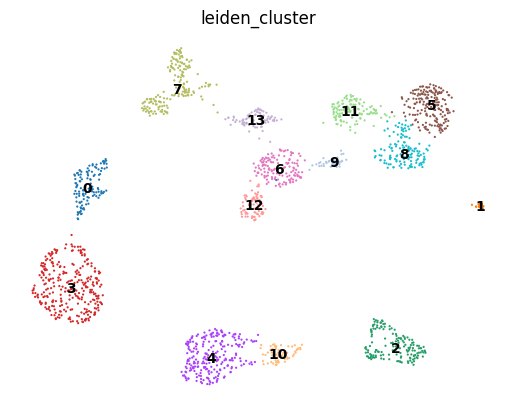

categories: 0, 1, 2, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


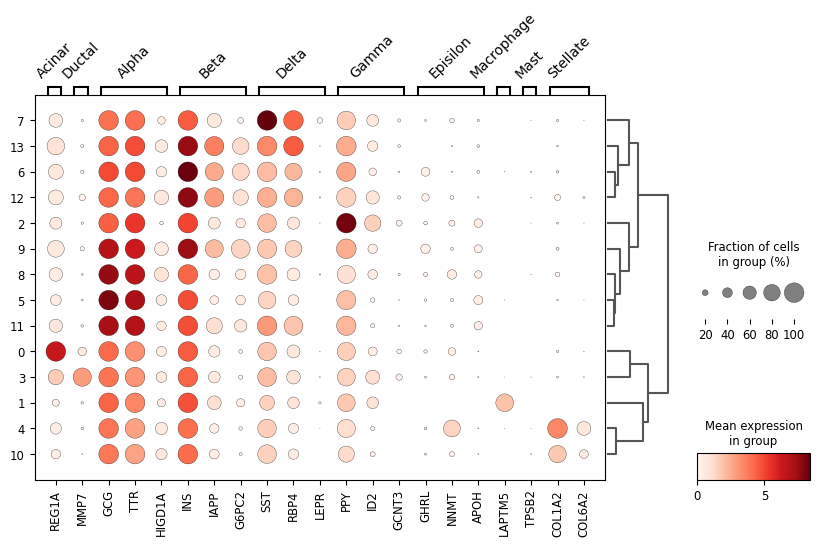

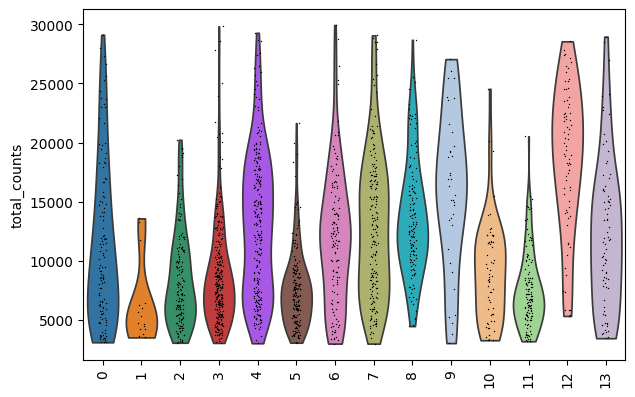

In [5]:
manual_validation = pipeline(validation)

### Cell Type Annotation Rationale

Acinar (Cluster 0): Highest mean expression of REG1A

Ductal (Cluster 3): Highest mean expession of MMP7.

Alpha (Cluster 8,5,11): Had the highest expression of GCG and TTR and lower expression of Beta genes.

Beta (Cluster 9,12,6): Had higher expression of beta genes than other genes. For cluster 9, it looked like a mix of beta and alpha, but I made the decision from the expression of IN5, which is much less than amost every other cluster.

Delta (Cluster 7, 13): Highest expression of SST and RBP4

Gamma (Cluster 2): Only cluster that had high expression of PPY and higher expression of ID2.

Episilon (Cluster 4): Only cluster that expressed any Episilon genes (NNMT)

Macrophage (Cluster 1): Only cluster that has expression of LAPTM5.

Mast- No cluster seem to express any mast cell genes

Stellate (Cluster 10): Highest mean expression of COL1A2 and COL6A2.

In [6]:
my_annotations= {'0': 'Acinar',
                 '1':'Macrophage',
                 '2': 'Gamma',
                 '3': 'Ductal',
                 '4': 'Epsilon',
                 '5': 'Alpha',
                 '6': 'Beta',
                 '7': 'Delta',
                 '8': 'Alpha',
                 '9': 'Beta',
                 '10': 'Stellate',
                 '11': 'Alpha',
                 '12':'Beta',
                 '13':'Delta'}
manual_validation.obs['manual_celltype'] = (manual_validation.obs['leiden_cluster'].map(my_annotations).fillna('Unknown').astype(str))

In [47]:
#mask to filter out cells with placeholder/unclear annotations
#'update_me' and 'Unknown' are temporary labels that aren't used in evaluation
valid_mask = ~manual_validation.obs['manual_celltype'].isin(['update_me', 'Unknown'])

#comparing between true and predicted annotations
y_true =manual_validation.obs.loc[valid_mask, 'cell_type']
y_pred = manual_validation.obs.loc[valid_mask, 'manual_celltype']

#get the statistics from sklearn
manual_report= classification_report(y_true, y_pred, output_dict=True)
manual_f1_macro= f1_score(y_true, y_pred, average='macro', zero_division=0)
manual_accuracy = accuracy_score(y_true, y_pred)

print(f'\nManual Annotation - Macro F1: {manual_f1_macro:.3f} | Accuracy: {manual_accuracy:.3f}\n')
print(classification_report(y_true, y_pred, zero_division=0))


Manual Annotation - Macro F1: 0.670 | Accuracy: 0.674

              precision    recall  f1-score   support

      Acinar       0.93      1.00      0.96       114
       Alpha       0.65      0.97      0.78       300
        Beta       0.83      0.70      0.76       290
       Delta       0.74      0.64      0.69       298
      Ductal       1.00      0.96      0.98       300
     Epsilon       0.00      0.00      0.00       108
       Gamma       0.53      0.72      0.61       112
  Macrophage       1.00      0.94      0.97        17
    Stellate       0.84      0.17      0.29       292

    accuracy                           0.67      1831
   macro avg       0.72      0.68      0.67      1831
weighted avg       0.75      0.67      0.67      1831



<a id='bbknn'></a>
## 1.2 BB-KNN



### BB-KNN Pipeline:

1. Prepare datasets for integration
   - Create copies of training and validation data
   - Add a 'study' label to identify which dataset each cell comes from
   - Training cells labeled as 'training', validation cells as 'validation'

2. Combine datasets
   - Concatenate training and validation into a single AnnData object
   - Make cell names unique to avoid conflicts
   - Verify the number of cells from each study

3. Preprocess combined data
   - Filter genes expressed in fewer than 3 cells
   - Store raw counts in a layer (preserving original data)
   - Normalize total counts per cell to 10,000
   - Log-transform the data
   - Identify highly variable genes (HVGs) accounting for 'study' differences

4. Dimensionality reduction with batch correction
   - Subset to highly variable genes only
   - Run PCA on the HVG subset
   - apply BBKNN to build a graph that balances neighbors across batches
  

5. Visualization and clustering
   - compute UMAP coordinates
   - perform Leiden clustering to identify cell populations
   
6. Mapping from clusters to reference cell types
    - For each Leiden cluster, look at the training cells within that cluster
    - Find the most common cell type among those training cells (mode)
    - if a cluster contains only validation cells, label it as 'Unknown'
    - map each validation cell's cluster ID to the reference label

7. Statistics
   - plot UMAP colored by predicted labels
   - calculate metrics on validation cells using sklearn

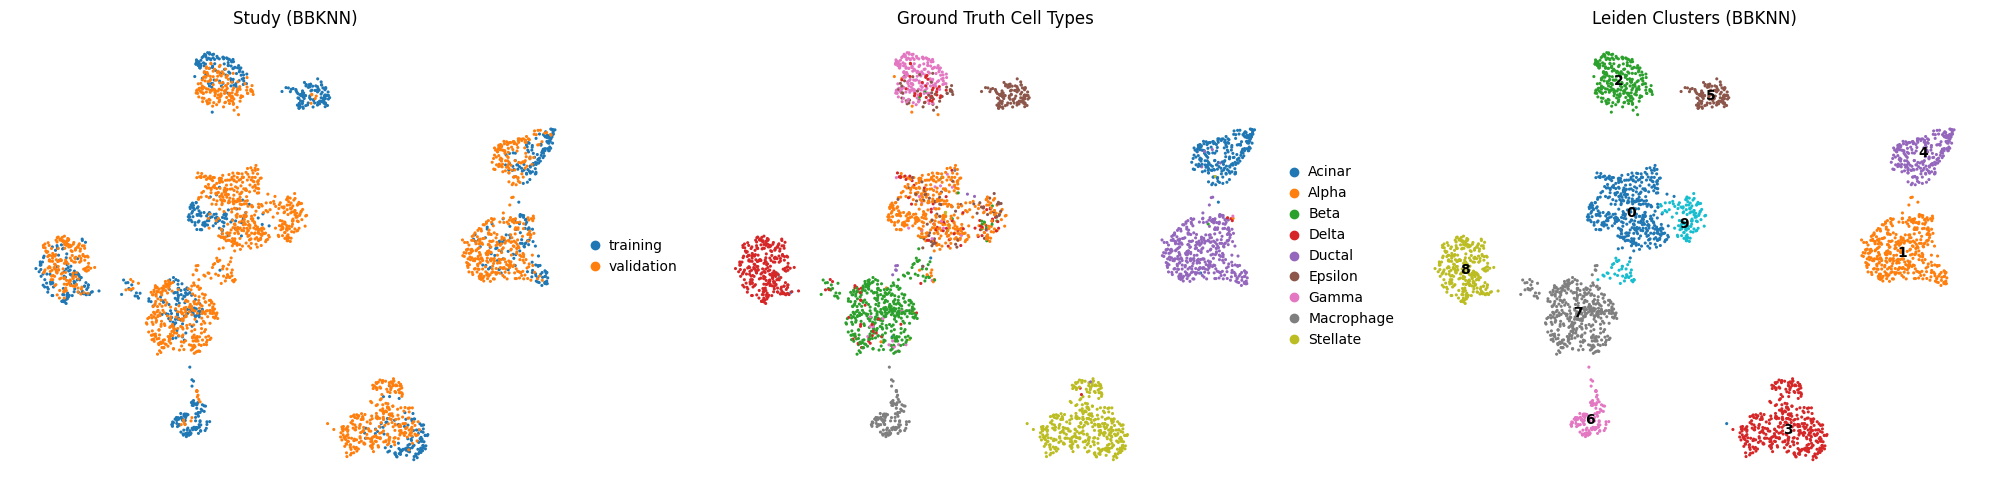

In [9]:
#creating copy of the datasets
ad_train_bbknn = training.copy()
ad_val_bbknn = validation.copy()
ad_train_bbknn.obs['study'] = 'training'
ad_val_bbknn.obs['study']= 'validation'

#concatenate the 2 datasets together
ad_bbknn = ad.concat([ad_train_bbknn, ad_val_bbknn])
ad_bbknn.obs_names_make_unique()

#preprocessing on the dataset before bbknn
sc.pp.filter_genes(ad_bbknn, min_cells=3)
ad_bbknn.layers['counts'] = ad_bbknn.X.copy()
sc.pp.normalize_total(ad_bbknn)
sc.pp.log1p(ad_bbknn)
sc.pp.highly_variable_genes(ad_bbknn, n_top_genes=2000, flavor='cell_ranger', batch_key='study')

#subset the HVGs so that we only used important genes
ad_bbknn_hvg = ad_bbknn[:, ad_bbknn.var['highly_variable']].copy()
sc.pp.pca(ad_bbknn_hvg)

sc.external.pp.bbknn(ad_bbknn_hvg, batch_key='study')

#embed and cluster
sc.tl.umap(ad_bbknn_hvg)
sc.tl.leiden(ad_bbknn_hvg, resolution=0.4, flavor='igraph', n_iterations=2, key_added='leiden_cluster')


fig, axes= plt.subplots(1, 3, figsize=(20, 5))
sc.pl.umap(ad_bbknn_hvg, color='study', size=20, frameon=False,
           title='Study (BBKNN)', ax=axes[0], show=False)
sc.pl.umap(ad_bbknn_hvg, color='cell_type', size=20, frameon=False,
           title='Ground Truth Cell Types', ax=axes[1], show=False)
sc.pl.umap(ad_bbknn_hvg, color='leiden_cluster', legend_loc='on data',
           size=20, frameon=False, title='Leiden Clusters (BBKNN)', ax=axes[2], show=False)
plt.tight_layout()
plt.show()

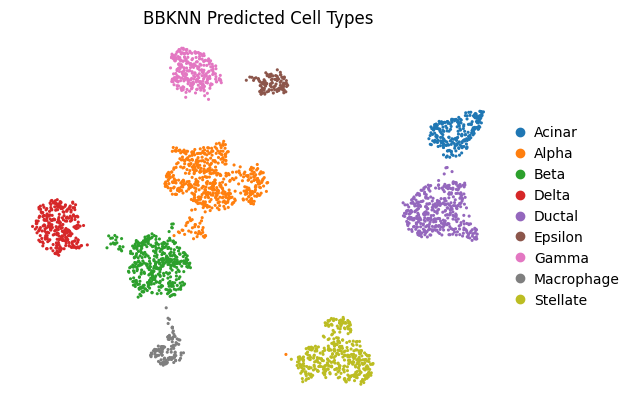


BBKNN - Macro F1: 0.762 | Accuracy: 0.823

              precision    recall  f1-score   support

      Acinar       0.94      0.98      0.96       121
       Alpha       0.62      0.99      0.76       300
        Beta       0.82      0.85      0.84       300
       Delta       1.00      0.60      0.75       300
      Ductal       0.98      0.95      0.97       300
     Epsilon       1.00      0.05      0.09       109
       Gamma       0.53      0.73      0.61       114
  Macrophage       1.00      0.82      0.90        17
    Stellate       0.99      0.97      0.98       300

    accuracy                           0.82      1861
   macro avg       0.88      0.77      0.76      1861
weighted avg       0.87      0.82      0.81      1861



In [48]:
#Label transfer: assign each validation cell the most common reference
cluster_ref_labels= {}
for cluster in ad_bbknn_hvg.obs['leiden_cluster'].unique():
    mask_cluster= ad_bbknn_hvg.obs['leiden_cluster'] == cluster
    mask_train= ad_bbknn_hvg.obs['study'] == 'training'
    #get cell types of training cells that fall in this cluster
    ref_cells= ad_bbknn_hvg.obs.loc[mask_cluster & mask_train, 'cell_type']
    #if there are training cells in this cluster, assign the most common cell type
    if len(ref_cells) > 0:
        cluster_ref_labels[cluster]= ref_cells.value_counts().idxmax()
    else:
        cluster_ref_labels[cluster] = 'Unknown'

#map cluster labels to predicted cell types for all cells
ad_bbknn_hvg.obs['bbknn_predicted'] = (ad_bbknn_hvg.obs['leiden_cluster'].map(cluster_ref_labels).astype(str))

#visualize the predicted labels on umap
sc.pl.umap(ad_bbknn_hvg, color='bbknn_predicted', size=20, frameon=False,
           title='BBKNN Predicted Cell Types', save='_bbknn_predicted.png')

#get the predicted and the true masks of the cells
val_mask_bbknn = ad_bbknn_hvg.obs['study'] == 'validation'
y_true_bbknn = ad_bbknn_hvg.obs.loc[val_mask_bbknn, 'cell_type']
y_pred_bbknn = ad_bbknn_hvg.obs.loc[val_mask_bbknn, 'bbknn_predicted']

#get the sklearn metrics
bbknn_f1_macro = f1_score(y_true_bbknn, y_pred_bbknn, average='macro', zero_division=0)
bbknn_accuracy = accuracy_score(y_true_bbknn, y_pred_bbknn)
print(f'\nBBKNN - Macro F1: {bbknn_f1_macro:.3f} | Accuracy: {bbknn_accuracy:.3f}\n')
print(classification_report(y_true_bbknn, y_pred_bbknn, zero_division=0))

categories: 0, 1, 2, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


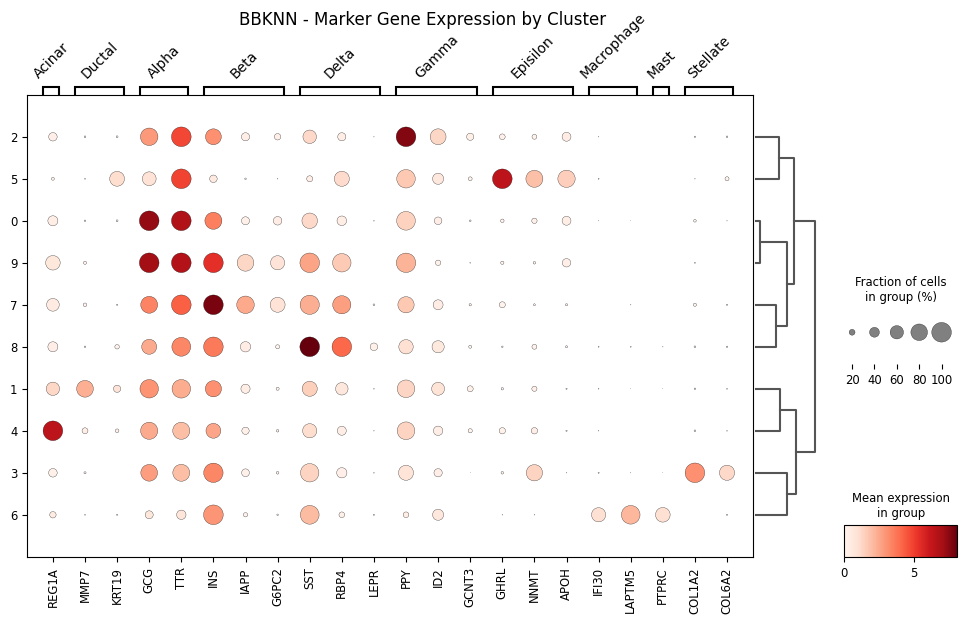

categories: Acinar, Alpha, Beta, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


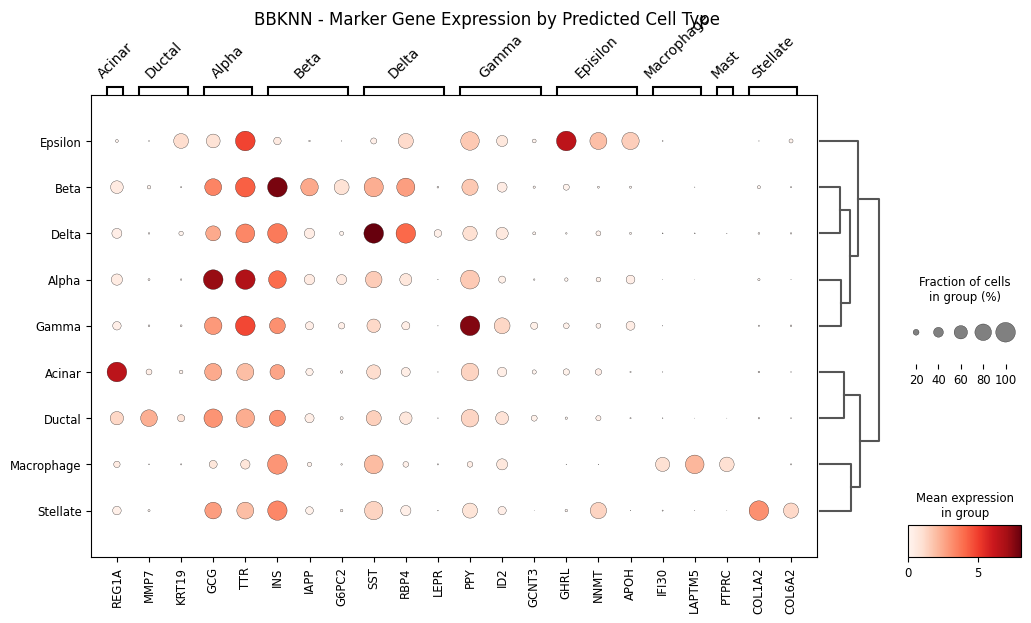

In [12]:
#dotplot to show the clusters
marker_genes = {'Acinar': ['PRSS2', 'REG1A'],
                'Ductal': ['MMP7', 'KRT19'],
                'Alpha': ['GCG', 'TTR', 'HIGD1A'],
                'Beta': ['INS', 'IAPP', 'G6PC2'],
                'Delta': ['SST', 'RBP4', 'LEPR'],
                'Gamma': ['PPY', 'ID2', 'GCNT3'],
                'Episilon': ['GHRL', 'NNMT', 'APOH'],
                'Macrophage': ['IFI30', 'LAPTM5'],
                'Mast': ['TPSB2', 'PTPRC'],
                'Stellate': ['COL1A2', 'COL6A2']}

#This follows the same filtering in the pipeline function code
filtered_markers = {}
for cell_type, genes in marker_genes.items():
    present_genes = [g for g in genes if g in ad_bbknn_hvg.var_names]
    if present_genes:
        filtered_markers[cell_type] = present_genes

#dotplot to validate cluster identities
sc.pl.dotplot(ad_bbknn_hvg, filtered_markers, groupby='leiden_cluster',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='BBKNN - Marker Gene Expression by Cluster\n\n\n')

#dotplot showing predicted cell types vs marker expression
sc.pl.dotplot(ad_bbknn_hvg, filtered_markers, groupby='bbknn_predicted',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='BBKNN - Marker Gene Expression by Predicted Cell Type\n\n\n')
plt.show()

<a id='scn'></a>
## 1.3 pySingleCellNet Classification

### pySCN (Single Cell Classifier) Pipeline:

1. Prepare data for classifier training
   - Create copies of training and validation datasets
   - Restrict both datasets to common genes only (ensuring features match)

2. Split training data into train and held-out sets
   - Split reference data into two partitions:
     - Training partition: Used to train the classifier
     - Held-out partition: Used for calibration (setting confidence thresholds)
   - Split by cell type (stratified) to maintain class balance

3. Preprocess training partition
   - Identify highly variable genes (top 3000 genes)
   - Normalize total counts per cell
   - Apply log transformation

4. Train pySCN classifier
   - Extract random gene pairs as features (nTopGenePairs=40)
   - Use random projections to create robust feature space
   - Train random forest classifier
   - Parameters control:
     - `nRand`: Number of random samples per class
     - `nTopGenes`: Top genes to consider for pairing
     - `n_comps`: Number of components for dimensionality reduction

5. Evaluate on held-out set and calibrate thresholds
   - Apply classifier to held-out cells
   - Generate classification report (precision, recall, F1 per class)
   - Visualize performance as heatmap

6. Build cell type relationship graph*
   - Compute PAGA (Partition-Based Graph Abstraction) on training data
   - Create graph showing transcriptional relationships between cell types
   - Used later to categorize predictions (correct/incorrect/novel)

7. Classify validation dataset
   - Apply trained classifier to all validation cells
   - Generate prediction scores for each cell type
   - Assign each cell to the class with highest score (`SCN_class_argmax`)

8. Categorize predictions
   - Compare prediction scores against thresholds from held-out set
   - Assign each prediction to a category:
     - Correct: High confidence, matches expected relationships
     - Uncertain: Below confidence threshold
     - Incorrect: Confident but wrong (contradicts relationship graph)
     - Novel: Doesn't fit known cell type relationships

9. statistics
    - Generate classification report with sklearn (precision, recall, F1 per class)
    - compare with UMAP

Training classifier |████████████████████████████████████████| 5/5 [100%] in 16.4s (0.30/s) 

Classification thresholds (5% FPR):
                  0
Acinar      0.67195
Alpha       0.52000
Beta        0.52335
Delta       0.60625
Ductal      0.60790
Epsilon     0.53270
Gamma       0.35640
Macrophage  0.53980
Stellate    0.86460


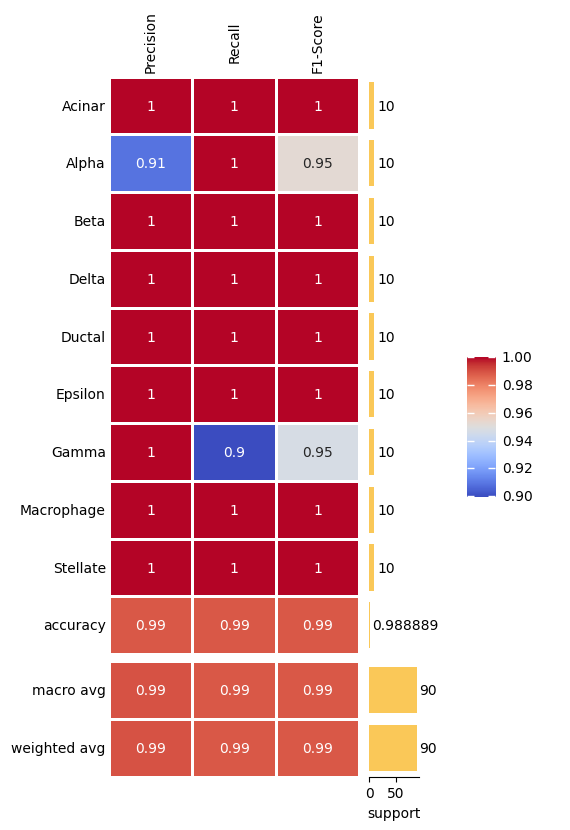

In [15]:
adRef= training.copy()
adVal= validation.copy()

#limit to common genes in both training and validation
cn.ut.limit_anndata_to_common_genes([adRef, adVal])

n_cells = 100
groupby = 'cell_type'

#get indices for training and held-out cells
tids, vids = cn.ut.split_adata_indices(adRef, n_cells, groupby=groupby)

adTrain_scn = adRef[tids].copy()
#internal held-out for calibration
adHO_scn= adRef[vids].copy()


#preprocess training partition (same as what I did in my pipeline function)
sc.pp.highly_variable_genes(adTrain_scn, n_top_genes=3000, flavor='seurat_v3')
sc.pp.normalize_total(adTrain_scn)
sc.pp.log1p(adTrain_scn)

#train the classifer on the training partition
#I just followed from the turtorial for these parameters
n_rand = n_cells
nTopGenes = 30
nTopGenePairs = 40
n_comps = 30

clf = cn.tl.train_classifier(adTrain_scn, groupby, nRand=n_rand,nTopGenes=nTopGenes, nTopGenePairs=nTopGenePairs, n_comps=n_comps)

#evaluate on internal held-out (to get calibration thresholds)
cn.tl.classify_anndata(adHO_scn, clf)
c_report_ho = cn.tl.create_classifier_report(adHO_scn, ground_truth=groupby, prediction='SCN_class_argmax')
cn.pl.heatmap_classifier_report(c_report_ho)

#classification thresholds based on held-out set
#determines confidence cutoffs for each cell type at 5% false positive rate
tThrs = cn.tl.comp_ct_thresh(adHO_scn, 0.05)
print('\nClassification thresholds (5% FPR):')
print(tThrs)

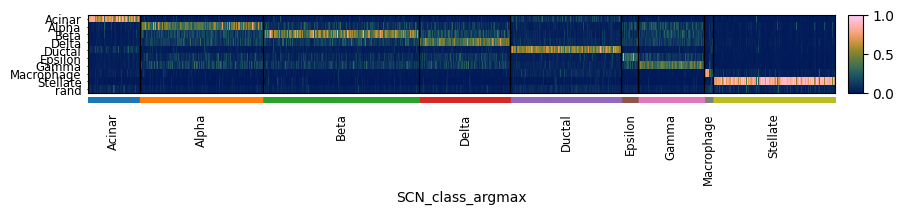

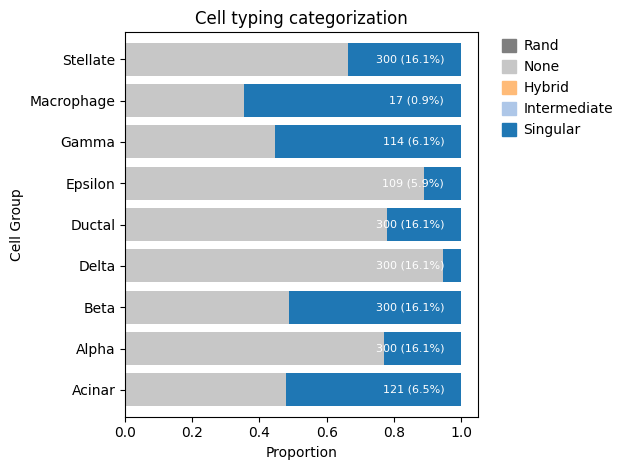


pySCN - Macro F1: 0.792 | Accuracy: 0.834

              precision    recall  f1-score   support

      Acinar       0.91      0.98      0.94       121
       Alpha       0.74      0.76      0.75       300
        Beta       0.74      0.97      0.84       300
       Delta       0.91      0.69      0.78       300
      Ductal       1.00      0.92      0.96       300
     Epsilon       0.68      0.26      0.37       109
       Gamma       0.55      0.79      0.65       114
  Macrophage       0.76      0.94      0.84        17
    Stellate       0.98      1.00      0.99       300

    accuracy                           0.83      1861
   macro avg       0.81      0.81      0.79      1861
weighted avg       0.85      0.83      0.83      1861



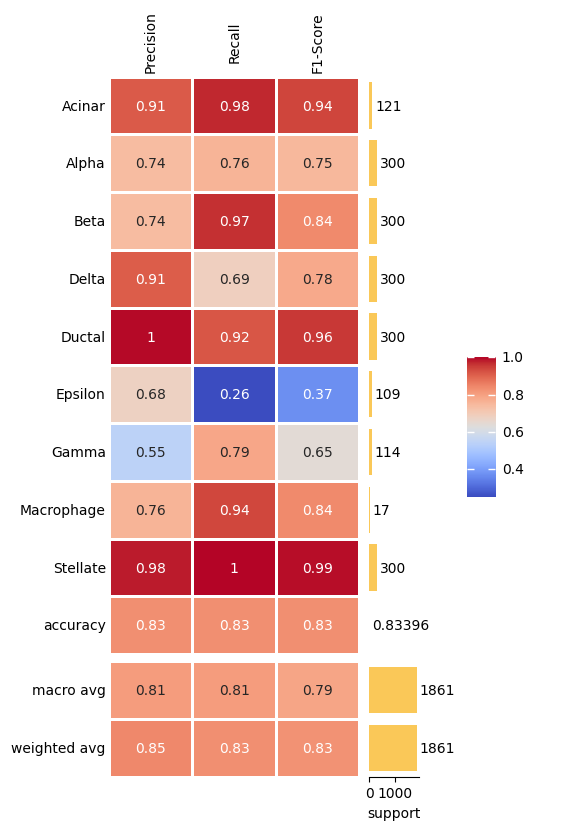

In [49]:
#PAGA-based graph showing relationships between cell types
#used for categorizing uncertain predictions
rela_graph = cn.tl.paga_connectivities_to_igraph(
    adTrain_scn, threshold=0.3, n_comps=30, group_key=groupby)

#classify the validation dataset
cn.tl.classify_anndata(adVal, clf)
cn.tl.categorize_classification(adVal, tThrs, rela_graph)

cn.pl.heatmap_scores(adVal, groupby='SCN_class_argmax')
cn.pl.stackedbar_categories(adVal, class_col_name='cell_type', show_pct_total=True)
plt.show()


c_report_val = cn.tl.create_classifier_report(adVal, ground_truth=groupby, prediction='SCN_class_argmax')
cn.pl.heatmap_classifier_report(c_report_val)

#get the sklearn metrics, which is same code as the bbknn and manual
y_true_scn = adVal.obs['cell_type']
y_pred_scn = adVal.obs['SCN_class_argmax']
scn_f1_macro = f1_score(y_true_scn, y_pred_scn, average='macro', zero_division=0)
scn_accuracy = accuracy_score(y_true_scn, y_pred_scn)
print(f'\npySCN - Macro F1: {scn_f1_macro:.3f} | Accuracy: {scn_accuracy:.3f}\n')
print(classification_report(y_true_scn, y_pred_scn, zero_division=0))

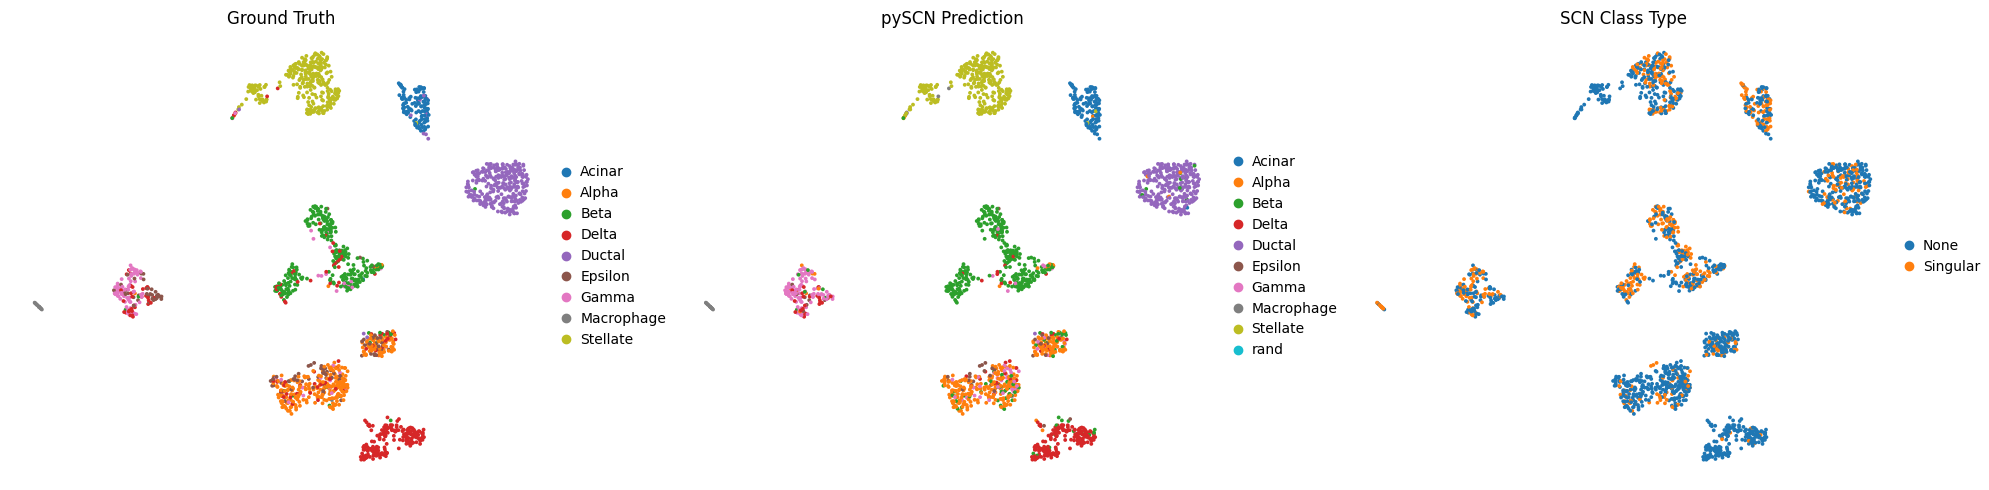

In [18]:
#UMAP of validation with pySCN labels
#follows the same preprocessing steps as before
adVal_viz = adVal.copy()
adVal_viz.layers['counts'] = adVal_viz.X.copy()
sc.pp.normalize_total(adVal_viz)
sc.pp.log1p(adVal_viz)
sc.pp.highly_variable_genes(adVal_viz, n_top_genes=3000, flavor='seurat_v3', layer='counts')
sc.tl.pca(adVal_viz, mask_var='highly_variable')
sc.pp.neighbors(adVal_viz, n_neighbors=10, n_pcs=30)
sc.tl.umap(adVal_viz)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sc.pl.umap(adVal_viz, color='cell_type', size=30, frameon=False,
           title='Ground Truth', ax=axes[0], show=False)
sc.pl.umap(adVal_viz, color='SCN_class_argmax', size=30, frameon=False,
           title='pySCN Prediction', ax=axes[1], show=False)
sc.pl.umap(adVal_viz, color='SCN_class_type', size=30, frameon=False,
           title='SCN Class Type', ax=axes[2], show=False)
plt.tight_layout()
plt.show()

categories: Acinar, Alpha, Beta, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


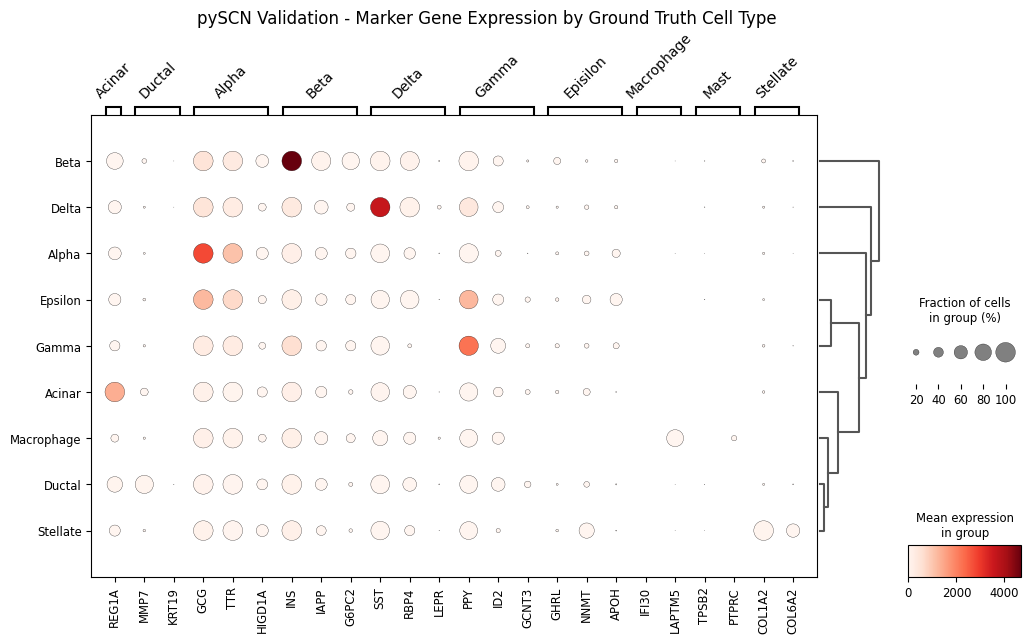

In [23]:
#dotplot for the SCN data
filtered_markers_scn = {}
for cell_type, genes in marker_genes.items():
    present_genes = [g for g in genes if g in adVal.var_names]
    if present_genes:
        filtered_markers_scn[cell_type] = present_genes

sc.pl.dotplot(adVal, filtered_markers_scn, groupby='cell_type',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='pySCN Validation - Marker Gene Expression by Ground Truth Cell Type\n\n\n\n')

<a id='1result'></a>

## 1.4 Results

When comparing manual annotation, classification-based (pySCN), and integration-based (BB-KNN) for predicting cell type identity from scRNA-seq, the classification-based method demonstrates superior overall performance with a Macro F1 score of 0.792 and accuracy of 0.834, compared to BBKNN's Macro F1 of 0.762 and accuracy of 0.823, while manual annotation lags significantly behind with a Macro F1 of only 0.670 and accuracy of 0.674. This 12 percentage points gap in Macro F1 between pySCN and manual annotation shows the power of computational approaches to leverage complex gene expression patterns that may not be apparent to human annotators. As a person manually annotating, I am using my dotplot and the size and color intensity of the dots to make my judegments, which is not statistically supported. I also have to have a lot of domain knowledge on the topic to identify cell types, which these machine learning models do not need.  

The superior performance of pySCN is due to its ability to maintain balanced accuracy and sensitivity across all nine cell types present in the validation data, showing its strength in handling challenging populations like Epsilon cells where it achieved a recall of 0.26 and F1 score of 0.37. It was the only method capable of meaningfully detecting this rare cell type. In contrast, BB-KNN failed in detecting Epsilon cells with a recall of 0.05, correctly identifying only 5 out of every 100 Epsilon cells while also achieving perfect precision of 1.00 for this same population. This showed the precision-recall tradeoff where high confidence predictions come at the cost of missing many true positive cells. This pattern extended to other rare populations as well in BB-KNN. BBKNN achieved perfect precision for Macrophage cells (1.00) and Delta cells (1.00) but at the expense of reduced recall for Delta (0.60), suggesting that integration-based methods may be overly conservative in their label transfer, only assigning rare cell type labels when the evidence is overwhelming while defaulting to more common identities for ambiguous cells.

Manual annotation showed the most extreme version of this conservative bias, achieving high precision for several rare types, including perfect precision for Ductal cells (1.00) and Macrophage cells (1.00), but demonstrating sensitivity for challenging populations, with failure to detect any Epsilon cells (0.00 recall) and detection of only 17% of Stellate cells, resulting in an F1 score of just 0.29 for this abundant pancreatic population despite its prevalence of 300 cells in the validation set. This might be just error on my part to correctly identify the cell type in my dotplot rather than the method's error.


The cell-type specific performance reveals some differences between methods: for Alpha cells, pySCN achieved balanced precision (0.74) and recall (0.76) for an F1 of 0.75, while BB-KNN showed excellent recall (0.99) but poorer precision (0.62) resulting in a similar F1 of 0.76, indicating different error profiles where BB-KNN tends to over-predict Alpha identity while pySCN makes more balanced misclassifications. For Beta cells, pySCN excelled with recall of 0.97 and F1 of 0.84, correctly identifying nearly all Beta cells while maintaining good precision, compared to BB-KNN's more moderate recall of 0.85 and manual annotation's recall of only 0.70, suggesting that human annotators may struggle to distinguish Beta cells from similar endocrine populations. For Delta cell population, BB-KNN achieved perfect precision (1.00) but only 0.60 recall, meaning every cell it labeled as Delta was correct, but it missed 40% of true Delta cells. pySCN has a better balance with 0.91 precision and 0.69 recall for an F1 of 0.78, while manual annotation showed the opposite pattern with lower precision (0.74) but comparable recall (0.64). For the Gamma cell population, pySCN again provided the most balanced performance with precision of 0.55 and recall of 0.79 (F1=0.65), while BBKNN showed lower precision (0.53) but higher recall (0.73), and manual annotation performed similarly to BBKNN. The Macrophage population, despite having only 17 cells in the validation set, was handled well by all methods, though BBKNN stood out with perfect precision and 0.82 recall (F1=0.90), suggesting that its batch-balanced approach may be particularly effective for clearly distinct immune populations. Stellate cells, failed in manual annotation with recall of only 0.17 despite an F1 of 0.99 from pySCN and 0.98 from BB-KNN, indicating that these cells express clear transcriptional signatures that computational methods readily detect but which may be easily overlooked or misidentified by human annotators relying on marker gene inspection alone.

The weighted average metrics support these conclusions, with pySCN achieving 0.85 precision, 0.83 recall, and 0.83 F1 compared to BB-KNN's 0.87 precision, 0.82 recall, and 0.81 F1, and manual annotation's 0.75 precision, 0.67 recall, and 0.67 F1, demonstrating that while BB-KNN achieves higher overall precision, pySCN provides better recall and F1 scores.

From my results, classification-based methods provide the most reliable and balanced approach for cell type prediction, particularly when dealing with heterogeneous populations containing rare or subtly distinct cell types. Integration-based methods can achieve higher precision for specific populations through conservative label transfer but risk completely missing some cell types, while manual annotation, despite showing high precision for well-characterized, transcriptionally distinct types, lacks the sensitivity and consistency necessary for comprehensive cell type identification across diverse cellular populations and may systematically underestimate cellular heterogeneity by failing to detect transcriptionally similar but biologically distinct populations.


<a id='question-2'></a>
# 2. How do you think an ideal cell-typing method should handle hybrids?

An ideal cell-typing method should handle hybrids not by forcing them into discrete categories, but by representing them as probabilistic mixtures of reference types. The pciSeq approach describes outputing a probability distribution across cell classes. For a true hybrid between Acinar and Beta cells, an ideal method would return something like '60% Acinar, 40% Beta' rather than forcing a binary choice based on which signature dominates. This probabilistic output would immediately flag the cell as intermediate and prompt further investigation.

Distinguishing true hybrids from doublets requires using spatial information. In pciSeq, each RNA read in the tissue is assigned to whichever cell nucleus it's closest to. Since some reads land far from any nucleus (orphaned reads), the method includes a probability term that accounts for the chance a read doesn't actually belong to any cell. A true hybrid should show consistent mixing of parent-type transcripts within the same cell body, while a doublet would show two distinct transcriptional programs that spatially separate into different nuclear territories. The hierarchical approach recommended in the Nanostring blog states to first establish broad types, then performing fine subtyping on a carefully selected gene set, which can help identify hybrids from doublets. True hybrids should show coordinated expression of genes from both parent programs while doublets might show mutually exclusive expression patterns.

Cells from the same developmental lineage should be treated differently than cells from distant lineages when evaluating hybrids. A hybrid between Alpha and Beta cells (both pancreatic endocrine, sharing developmental origin) is biologically plausible since they arise from common progenitors and share core transcriptional programs. A hybrid between Alpha and Stellate (mesenchymal origin) would be a bit suspicious. An ideal method would incorporate lineage distance as a prior: hybrids between closely related types should be treated as more plausible than distant cell types. We can do this using a correlation analysis. Genes from both parent should show positive correlation with each other across cells. As a cell becomes more hybrid-like, it upregulates genes from both parents coordinately. In doublets, genes from different parents should be uncorrelated or even negatively correlated (since they come from different cells entirely). We can use a UMAP to see if hybrids are at a continuous bridge between parental clusters. Doublets might appear as a distinct separate cluster disconnected from both parents. Doublets are more common in dissociated samples and should correlate with dissociation artifacts (like high mitochondrial percentage, stress markers, or nearly double the library size). We can compute a ratio of parent1-marker expression to parent2-marker expression per cell, and plot against total UMI count. Doublets would cluster at high UMI with bimodal marker ratios, while true hybrids would sit at normal UMI counts with intermediate ratios.

Also, hybrids often represent transition states along a differentiation trajectory. If we have time-series data (days post-transplantation, like in our query data), a true hybrid should either resolve into a pure type over time or represent a stable intermediate. Doublets are static artifacts, so they probably won't show temporal progression. An ideal method would leverage longitudinal samples to distinguish transitional states from technical artifacts if possible.

Context of where the dataset matters as well. In healthy tissues, hybrids should be rare and lineage-restricted. We should expect them only at known plasticity boundaries. Prior knowledge of tissue architecture is also important. If a hybrid appears in a location where the two parent types never physically interact, it might be a doublet. Tumors actively generate true hybrids through things like epithelial-mesenchymal transition (EMT), where carcinoma cells acquire mesenchymal features. We can look for  EMT transcription factor expression in potential hybrid cells, which indicate active transition. We can also check immune ligand-receptor markers. If tumor-macrophage hybrid shows T-cell engagement markers, it might be a doublet from immune cell-tumor cell interaction during antigen presentation. In engineered cells, creating hybrids might be goal, which makes it more difficult to identify hybrids vs doublets. We might want to look at intermediate functional properties, like partial insulin secretion + partial amylase production, which doublets might not have. We can use this information to make a continuous scoring system that reports a trajectory inference, like "this cell is 70% of the way along the acinar-to-beta trajectory".

Since hybrids are rare, so we wan to avoiding false positives (Type 1 error). The pciSeq approach of including a 'zero class' and modeling technical noise through gamma-distributed efficiency parameters provides a conservative baseline. Since many of the techniques in class used a reference dataset to train a machine learning model, an ideal method would incorporate engineered cells into the training data when available, and when not, would use a continuous scoring system against multiple reference types rather than discrete classification. One solution for engineered cell analysis is to use synthetic hybrids as training examples. Since we can generate hybrids at known mixing ratios (as I did in Question 3), these can be added to the reference training set so the classifier learns to recognize intermediate states rather than forcing them into parent categories. A classifier trained on pure cells plus synthetic hybrids at multiple alpha levels (0.3, 0.5, 0.7) would have explicit hybrid categories to assign cells to, rather than defaulting to whichever parent signature dominates. The advantage of this approach is that we don't need real engineered cell examples to get started. Instead, we can bootstrap a hybrid-aware classifier from any reference dataset. The limitation is that synthetic hybrids generated by linear mixing are a simplification.  Real engineered cells may have non-linear expression changes, stress responses, or novel gene programs that don't appear in either parent, so the synthetic training data may not fully capture what we do experimentally.

Sources:

Qian, X., Harris, K.D., Hauling, T. et al. Probabilistic cell typing enables fine mapping of closely related cell types in situ. Nat Methods 17, 101–106 (2020). https://doi.org/10.1038/s41592-019-0631-4

Danaher, P. Cell typing: advanced strategies https://nanostring-biostats.github.io/CosMx-Analysis-Scratch-Space/posts/cell-typing-strategies/cell-typing-strategies.html

Sinha, D., Saha, P., Samanta, A., & Bishayee, A. (2020). Emerging Concepts of Hybrid Epithelial-to-Mesenchymal Transition in Cancer Progression. Biomolecules, 10(11), 1561. https://doi.org/10.3390/biom10111561

<a id='question-3'></a>
# 3. How well do the three cell-typing methods above perform when analyzing populations that include hybrids?

### Hybrid Cell Generation Pipeline

1. Select Genes for Hybridization
    - Compute highly variable genes (HVGs) on a normalized copy of the data
      - Normalize to 10,000 counts per cell
      - Apply log1p transformation
      - Identify top `n_top_genes` (default: 2000) used seruat due to binning issues
    - Compute HVG index positions
    - HVGs capture the most informative variation between cell types
    - Non-HVG genes will be mixed 50/50 between parents (neutral, symmetric contribution)

2. Generate Synthetic Hybrid Cells

    - Iterate over all unique unordered pairs of cell types
    - For each pair, sample random parent cells from each type (with replacement)
    - For each hybridization level `alpha` in `[0.3, 0.5, 0.7]`:
      - HVG positions: `alpha*expr1 + (1-alpha)*expr2`
      - Non-HVG positions: `0.5*expr1 + 0.5*expr2`
      - Add small Gaussian noise (2% of mean expression) to increase realism
      - Clip to zero (no negative counts), round to integers
    - Store metadata per hybrid:
      - `parent1`, `parent2`, `alpha`, `mixing_ratio`
      - `parent1_cellid`, `parent2_cellid` (traceable back to original `adata`)
      - `sample_id` inherited from parent1
      - `is_hybrid = True`

3. Combine Hybrids with Validation Data
    - Tag original cells with `is_hybrid = False`
    - Concatenate original and hybrid AnnData objects

In [30]:
def generate_hybrid_cells(adata, n_hybrids_per_pair=20, hybridization_levels=[0.3, 0.5, 0.7],
                           use_hvg=True, n_top_genes=2000, random_seed=0):

    np.random.seed(random_seed)

    #pull unique cell types from the obs column
    cell_types = adata.obs['cell_type'].unique()
    print(f'Found {len(cell_types)} cell types: {list(cell_types)}')

    #report how many cells exist per type so we can anticipate any skips
    type_counts = adata.obs['cell_type'].value_counts()
    print('\nCells per type:')
    for ct, count in type_counts.items():
        print(f'   {ct}: {count} cells')

    #we identify highly variable genes on a normalised copy of the data
    #hybridization itself will happen on the original adata.X (raw counts)
    if use_hvg:
        print(f'\nCalculating highly variable genes (top {n_top_genes}):')
        temp_adata = adata.copy()
        sc.pp.normalize_total(temp_adata, target_sum=1e4)
        sc.pp.log1p(temp_adata)
        sc.pp.highly_variable_genes(temp_adata, n_top_genes=n_top_genes, flavor='seurat_v3')

        # boolean mask of which genes are HVGs
        hvg_mask = temp_adata.var['highly_variable'].values
        genes_to_use = temp_adata.var_names[hvg_mask]
        hvg_indices = np.where(hvg_mask)[0]

        print(f'Using {len(genes_to_use)} highly variable genes for hybridization')
        del temp_adata
    else:
        genes_to_use = adata.var_names
        # if using all genes, every index is an hvg index
        hvg_indices = np.arange(adata.shape[1])
        print(f'Using all {len(genes_to_use)} genes for hybridization')

    # containers to collect hybrids across all cell type pairs
    hybrid_X = []
    hybrid_metadata = []
    total_pairs = 0

   #generate the cell type hybrids
    for i, type1 in enumerate(cell_types):
        for j, type2 in enumerate(cell_types):
            #skip same-type pairs
            if i >= j:
                continue
            total_pairs+=1
            print(f'\nGenerating hybrids between {type1} and {type2}...')

            #subset to cells belonging to each type
            cells_type1= adata[adata.obs['cell_type'] == type1]
            cells_type2= adata[adata.obs['cell_type'] == type2]

            n_type1= cells_type1.shape[0]
            n_type2 = cells_type2.shape[0]

            #skip if either type has too few cells to sample from meaningfully
            min_cells_needed = 5
            if n_type1 < min_cells_needed or n_type2<min_cells_needed:
                print(f'  Skipping: need at least {min_cells_needed} cells per type '
                      f'({type1}: {n_type1}, {type2}: {n_type2})')
                continue

            #pre-draw all parent indices we will need for this pair
            total_hybrids_this_pair = n_hybrids_per_pair*len(hybridization_levels)
            type1_indices=np.random.choice(n_type1, total_hybrids_this_pair, replace=True)
            type2_indices=np.random.choice(n_type2, total_hybrids_this_pair, replace=True)
            #retrieve the original barcodes so we can trace back to adata later
            type1_barcodes=cells_type1.obs['cellid'].values
            type2_barcodes=cells_type2.obs['cellid'].values

            hybrid_count=0

            #loop over hybridization levels and individual hybrids
            for alpha in hybridization_levels:
                # alpha is the proportion contributed by type1
                # (1-alpha) is the proportion from type2
                for k in range(n_hybrids_per_pair):
                    idx1 =type1_indices[hybrid_count]
                    idx2 =type2_indices[hybrid_count]
                    #extract the expression vectors for both parent cells
                    expr1= cells_type1.X[idx1, :]
                    expr2 =cells_type2.X[idx2, :]

                    #convert sparse slices to dense 1-D arrays if necessary
                    if issparse(expr1):
                        expr1=expr1.toarray().flatten()
                        expr2=expr2.toarray().flatten()
                    else:
                        expr1=np.asarray(expr1).flatten()
                        expr2=np.asarray(expr2).flatten()

                    #start with copy of parent 1
                    hybrid_expr=expr1.copy()
                    hybrid_expr[hvg_indices]=(alpha*expr1[hvg_indices] + (1-alpha)*expr2[hvg_indices])

                    # for non-HVG genes use a 50/50 average
                    #rather than always defaulting to parent1
                    #prevent bias all hybrids toward type1 in those genes
                    non_hvg_indices=np.setdiff1d(np.arange(adata.shape[1]), hvg_indices)
                    hybrid_expr[non_hvg_indices]=(0.5*expr1[non_hvg_indices] + 0.5*expr2[non_hvg_indices])

                    #add a small amount of Poisson-like noise scaled to local expression
                    #genes tend to follows a Poission distribution before normalization
                    #np.maximum ensures we never get negative values
                    noise_scale=0.02*np.mean(hybrid_expr)
                    noise=np.random.normal(0, noise_scale, hybrid_expr.shape)
                    hybrid_expr=np.maximum(0, hybrid_expr+noise)

                    #round to integers
                    hybrid_expr= np.round(hybrid_expr).astype(np.float32)

                    hybrid_X.append(hybrid_expr)
                    hybrid_metadata.append({'cell_type':f'Hybrid_{type1}_{type2}',
                                          'parent1':type1,
                                          'parent2':type2,
                                          'alpha':alpha,
                                          'mixing_ratio':f'{alpha:.1f}_{type1}_{(1 - alpha):.1f}_{type2}',
                                          'is_hybrid':True,
                                          'hybridization_level':alpha,
                                          'parent1_cell_idx':idx1,
                                          'parent2_cell_idx':idx2,
                                          #store original barcodes so we can trace back to adata
                                          'parent1_cellid':type1_barcodes[idx1],
                                          'parent2_cellid':type2_barcodes[idx2],
                                          'n_genes_original':adata.shape[1],
                                          # copy over sample_id from parent1 for any downstream QC filters
                                          'sample_id':cells_type1.obs['sample_id'].values[idx1],})

                    hybrid_count += 1

            print(f'  Generated {hybrid_count} hybrids between {type1} and {type2}')

    if len(hybrid_X) == 0:
        print('\nWarning: no hybrids generated. check cell type counts and min_cells_needed.')
        return None, None

    hybrid_X_array=np.array(hybrid_X, dtype=np.float32)
    hybrid_meta_df=pd.DataFrame(hybrid_metadata)
    hybrid_meta_df.index=[f'hybrid_{i}' for i in range(len(hybrid_meta_df))]

    #build the hybrid AnnData, reusing var from the original so gene metadata is preserved
    hybrid_adata=sc.AnnData(X=hybrid_X_array,obs=hybrid_meta_df,var=adata.var.copy())

    #combine hybrids with the original validation data
    adata.obs['is_hybrid'] = False
    hybrid_adata.obs['is_hybrid'] = True
    combined_adata = sc.concat([adata, hybrid_adata], join='outer', label='source', keys=['original', 'hybrid'])

    #sc.concat drops var annotations, so we restore them from the original
    for col in adata.var.columns:
        combined_adata.var[col]=adata.var[col].values

    print(f'Hybrid Generation Summary')
    print(f'Original cells:        {adata.shape[0]}')
    print(f'Hybrid cells:          {hybrid_adata.shape[0]}')
    print(f'Combined dataset:      {combined_adata.shape[0]} cells x {combined_adata.shape[1]} genes')
    print(f'Cell type pairs:       {total_pairs}')
    print(f'Hybridization levels:  {hybridization_levels}')

    print(f'\nHybrid counts by type:')
    for ct, count in hybrid_adata.obs['cell_type'].value_counts().items():
        print(f'  {ct}: {count}')

    print(f'\nHybrid counts by mixing ratio:')
    for ratio, count in hybrid_adata.obs['mixing_ratio'].value_counts().items():
        print(f'  {ratio}: {count}')

    return combined_adata, hybrid_adata, hybrid_meta_df

In [32]:
combined_adata, hybrid_adata, hybrid_metadata = generate_hybrid_cells(validation)

Found 9 cell types: ['Acinar', 'Macrophage', 'Gamma', 'Ductal', 'Stellate', 'Alpha', 'Beta', 'Delta', 'Epsilon']

Cells per type:
   Alpha: 300 cells
   Stellate: 300 cells
   Beta: 300 cells
   Delta: 300 cells
   Ductal: 300 cells
   Acinar: 121 cells
   Gamma: 114 cells
   Epsilon: 109 cells
   Macrophage: 17 cells

Calculating highly variable genes (top 2000):
Using 2000 highly variable genes for hybridization

Generating hybrids between Acinar and Macrophage...
  Generated 60 hybrids between Acinar and Macrophage

Generating hybrids between Acinar and Gamma...
  Generated 60 hybrids between Acinar and Gamma

Generating hybrids between Acinar and Ductal...
  Generated 60 hybrids between Acinar and Ductal

Generating hybrids between Acinar and Stellate...
  Generated 60 hybrids between Acinar and Stellate

Generating hybrids between Acinar and Alpha...
  Generated 60 hybrids between Acinar and Alpha

Generating hybrids between Acinar and Beta...
  Generated 60 hybrids between Acinar

<a id='manual3'></a>
## 3.2 Manual Annotations

Hybrid cells were generated by averaging expression, so their QC metrics (total counts, pct_mt, n_genes) will look different from real cells. Many will likely get filtered out, which defeats the point. I decided to not do a lot of QC, especially sense the data already has some QC done to it.


I decided to keep my resolution as 0.5 instead of making it bigger for subpopulations and hybrid identification. The reason being that as a scientist, I am probably not really looking for hybrids specfically. I also want to compare to the pipeline I ran in question 1. In a real experimental setting, if engineered cells adopted hybrid or intermediate transcriptional states, they would need to be discoverable through standard analysis pipelines without parameter tuning specifically for that purpose. By maintaining consistent parameters, I can assess whether each method would alert me to the presence of unusual populations or simply absorb them into existing categories.

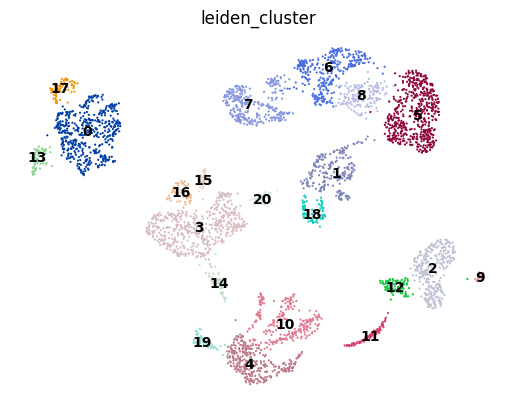

categories: 0, 1, 2, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


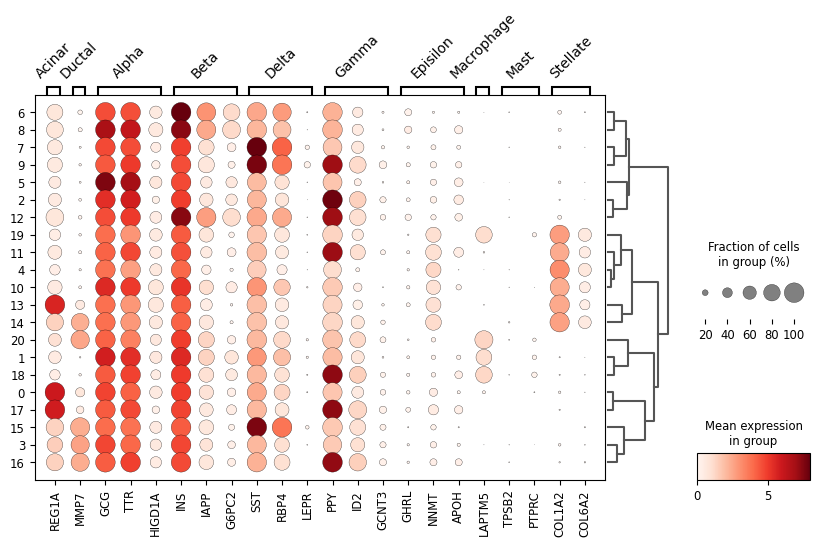

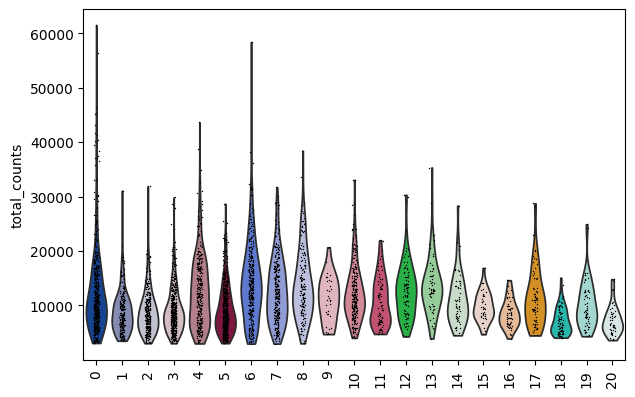

In [34]:
manual_validation_hybrid = pipeline(combined_adata,
                                    filter_mt=False,
                                    filter_counts=False,
                                    filter_genes=False)

### Cell Type Annotation Rationale

Acinar (Cluster 0): Highest mean expression of REG1A with no high expression of other genes.

Ductal (Cluster 3): Highest mean expession of MMP7 with no high expression of other cell type genes

Alpha (Cluster 5): Had the highest expression of GCG and TTR with no high expression of other cell type genes

Beta (Cluster 6): Had higher expression of beta genes than other genes with no obvious expression of other cell type genes

Delta (Cluster 7): Highest expression of SST and RBP4 with no obvious expression of other cell type genes

Gamma (Cluster 2): Cluster that had high expression of PPY and higher expression of ID2 without genes from other cell types

Macrophage (Cluster 1): Cluster that has expression of LAPTM5 without high expressions from other cell types.

Hybrid Stellate Epsilon (Cluster 4, 10): Has both NNMT and COL1A2 and COL6A2

Hybrid Alpha Beta (Cluster 8): had higher expression of GCG and TTR with INS compared to other clusters.

Hybrid Gamma Delta (Cluster 9): Highest expression of SST and RBP4 with high PPY

Hybrid Gamma Stellate (Cluster 11): Highest expression of SST and RBP4 with high COL1A2 and COL6A2

Hybrid Gamma Beta (Cluster 12): Highest expression of SST and RBP4 with higher expression of INS compared to other clusters

Hybrid Acinar Stellate (Cluster 13):

Hybrid Ductal Stellate (Cluster 14): Highest expression MMP7 with high COL1A2 and COL6A2

Hybrid Ductal Delta (Cluster 15): Highest expression MMP7 with high SST and RBP4

Hybrid Gamma Ductal (Cluster 16): Highest expression of SST and RBP4 with MMP7

Hybrid Acinar Gamma (Cluster 17): Highest expression of SST and RBP4 with some mean expression of REG1A as cluster 0

Hybrid Macrophage Gamma (Cluster 18): Highest expression of SST and RBP4 with LAPTM5

Hybrid Macrophage Stellate (Cluster 19): Highest expression of LAPTM5 with high COL1A2 and COL6A2

Hybrid Macrophage Ductal (Cluster 20): Highest expression of LAPTM5 with high MMP7

In [42]:
my_annotations_hybrid= {'0': 'Acinar',
                 '1':'Macrophage',
                 '2':'Gamma',
                 '3':'Ductal',
                 '4':'Hybrid_Stellate_Epsilon',
                 '5':'Alpha',
                 '6':'Beta',
                 '7': 'Delta',
                 '8':'Hybrid_Alpha_Beta',
                 '9':'Hybrid_Gamma_Delta',
                 '10': 'Hybrid_Stellate_Epsilon',
                 '11':'Hybrid_Gamma_Stellate',
                 '12': 'Hybrid_Gamma_Beta',
                 '13':'Hybrid_Acinar_Stellate',
                 '14':'Hybrid_Ductal_Stellate',
                 '15':'Hybrid_Ductal_Delta',
                 '16':'Hybrid_Gamma_Ductal',
                 '17':'Hybrid_Acinar_Gamma',
                 '18':'Hybrid_Macrophage_Gamma',
                 '19':'Hybrid_Macrophage_Stellate',
                 '20':'Hybrid_Macrophage_Ductal'}
manual_validation_hybrid.obs['manual_celltype'] = (manual_validation_hybrid.obs['leiden_cluster'].map(my_annotations_hybrid).fillna('Unknown').astype(str))

In [52]:
#mask to filter out cells with placeholder/unclear annotations
#'update_me' and 'Unknown' are temporary labels that aren't used in evaluation
valid_mask_hybrid = ~manual_validation_hybrid.obs['manual_celltype'].isin(['update_me', 'Unknown'])

#comparing between true and predicted annotations
y_true_hybrid =manual_validation_hybrid.obs.loc[valid_mask_hybrid, 'cell_type']
y_pred_hybrid = manual_validation_hybrid.obs.loc[valid_mask_hybrid, 'manual_celltype']

#get the statistics from sklearn
manual_report_hybrid= classification_report(y_true_hybrid, y_pred_hybrid, output_dict=True)
manual_f1_macro_hybrid= f1_score(y_true_hybrid, y_pred_hybrid, average='macro', zero_division=0)
manual_accuracy_hybrid = accuracy_score(y_true_hybrid, y_pred_hybrid)

print(f'\nManual Annotation - Macro F1: {manual_f1_macro_hybrid:.3f} | Accuracy: {manual_accuracy_hybrid:.3f}\n')
print(classification_report(y_true_hybrid, y_pred_hybrid, zero_division=0))


Manual Annotation - Macro F1: 0.274 | Accuracy: 0.444

                            precision    recall  f1-score   support

                    Acinar       0.25      0.99      0.40       121
                     Alpha       0.54      0.96      0.69       300
                      Beta       0.75      0.81      0.78       300
                     Delta       0.64      0.63      0.64       300
                    Ductal       0.59      0.96      0.73       300
                   Epsilon       0.00      0.00      0.00       109
                     Gamma       0.27      0.69      0.39       114
       Hybrid_Acinar_Alpha       0.00      0.00      0.00        60
        Hybrid_Acinar_Beta       0.00      0.00      0.00        60
       Hybrid_Acinar_Delta       0.00      0.00      0.00        60
      Hybrid_Acinar_Ductal       0.00      0.00      0.00        60
     Hybrid_Acinar_Epsilon       0.00      0.00      0.00        60
       Hybrid_Acinar_Gamma       0.62      0.73      0.67  

In [84]:
hybrid_mask_man = manual_validation_hybrid.obs['cell_type'].str.startswith('Hybrid_')

# pure cells only - remove update_me and Unknown as before
pure_valid_mask_man = ~hybrid_mask_man & ~manual_validation_hybrid.obs['manual_celltype'].isin(['update_me', 'Unknown'])

y_true_pure_man = manual_validation_hybrid.obs.loc[pure_valid_mask_man, 'cell_type']
y_pred_pure_man = manual_validation_hybrid.obs.loc[pure_valid_mask_man, 'manual_celltype']

print('Pure Validation Cells')
print(f'\nManual Annotation - Macro F1: {f1_score(y_true_pure_man, y_pred_pure_man, average="macro", zero_division=0):.3f} | Accuracy: {accuracy_score(y_true_pure_man, y_pred_pure_man):.3f}\n')
print(classification_report(y_true_pure_man, y_pred_pure_man, zero_division=0))

Pure Validation Cells

Manual Annotation - Macro F1: 0.349 | Accuracy: 0.658

                         precision    recall  f1-score   support

                 Acinar       0.94      0.99      0.96       121
                  Alpha       0.66      0.96      0.79       300
                   Beta       0.86      0.81      0.83       300
                  Delta       0.98      0.63      0.77       300
                 Ductal       1.00      0.96      0.98       300
                Epsilon       0.00      0.00      0.00       109
                  Gamma       0.52      0.69      0.60       114
 Hybrid_Acinar_Stellate       0.00      0.00      0.00         0
      Hybrid_Alpha_Beta       0.00      0.00      0.00         0
    Hybrid_Ductal_Delta       0.00      0.00      0.00         0
 Hybrid_Ductal_Stellate       0.00      0.00      0.00         0
      Hybrid_Gamma_Beta       0.00      0.00      0.00         0
    Hybrid_Gamma_Ductal       0.00      0.00      0.00         0
  Hybrid_Ga

In [130]:
# hybrid cells - what cluster label did manual annotation assign them
hybrid_obs_man = manual_validation_hybrid.obs[hybrid_mask_man].copy()
hybrid_obs_man['parent1'] = hybrid_obs_man['cell_type'].str.split('_').str[1]
hybrid_obs_man['parent2'] = hybrid_obs_man['cell_type'].str.split('_').str[2]

print('\nHybrid Cell Top Predictions')
summary = (hybrid_obs_man
           .groupby(['parent1', 'parent2', 'alpha'])['manual_celltype']
           .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown')
           .reset_index()
           .rename(columns={'manual_celltype': 'top_prediction'}))
print(summary.to_string())


Hybrid Cell Top Predictions
        parent1     parent2  alpha              top_prediction
0        Acinar       Alpha    0.3                      Acinar
1        Acinar       Alpha    0.5                      Acinar
2        Acinar       Alpha    0.7                      Acinar
3        Acinar        Beta    0.3                      Acinar
4        Acinar        Beta    0.5                      Acinar
5        Acinar        Beta    0.7                      Acinar
6        Acinar       Delta    0.3                      Acinar
7        Acinar       Delta    0.5                      Acinar
8        Acinar       Delta    0.7                      Acinar
9        Acinar      Ductal    0.3                      Acinar
10       Acinar      Ductal    0.5                      Acinar
11       Acinar      Ductal    0.7                      Acinar
12       Acinar     Epsilon    0.3                      Acinar
13       Acinar     Epsilon    0.5                      Acinar
14       Acinar     Epsilo

<a id='bbknn3'></a>
## 3.3 BB-KNN

Same code as in question 1

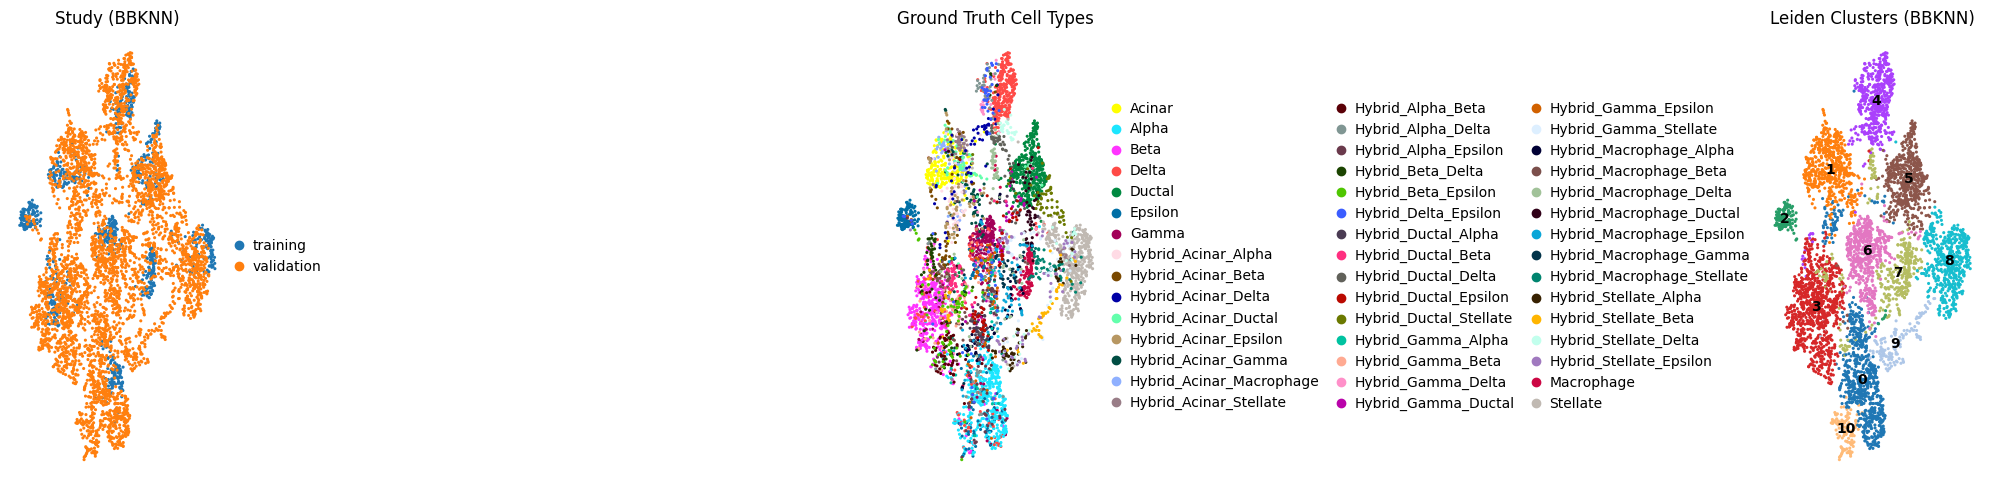

In [50]:
#creating copy of the datasets
ad_train_bbknn_hybrid = training.copy()
ad_val_bbknn_hybrid = combined_adata.copy()
ad_train_bbknn_hybrid.obs['study'] = 'training'
ad_val_bbknn_hybrid.obs['study']= 'validation'

#concatenate the 2 datasets together
ad_bbknn_hybrid = ad.concat([ad_train_bbknn_hybrid, ad_val_bbknn_hybrid])
ad_bbknn_hybrid.obs_names_make_unique()

#preprocessing on the dataset before bbknn
sc.pp.filter_genes(ad_bbknn_hybrid, min_cells=3)
ad_bbknn_hybrid.layers['counts'] = ad_bbknn_hybrid.X.copy()
sc.pp.normalize_total(ad_bbknn_hybrid)
sc.pp.log1p(ad_bbknn_hybrid)
sc.pp.highly_variable_genes(ad_bbknn_hybrid, n_top_genes=2000, flavor='cell_ranger', batch_key='study')

#subset the HVGs so that we only used important genes
ad_bbknn_hvg_hybrid = ad_bbknn_hybrid[:, ad_bbknn_hybrid.var['highly_variable']].copy()
sc.pp.pca(ad_bbknn_hvg_hybrid)

sc.external.pp.bbknn(ad_bbknn_hvg_hybrid, batch_key='study')

#embed and cluster
sc.tl.umap(ad_bbknn_hvg_hybrid)
sc.tl.leiden(ad_bbknn_hvg_hybrid, resolution=0.4, flavor='igraph', n_iterations=2, key_added='leiden_cluster')


fig, axes= plt.subplots(1, 3, figsize=(20, 5))
sc.pl.umap(ad_bbknn_hvg_hybrid, color='study', size=20, frameon=False,
           title='Study (BBKNN)', ax=axes[0], show=False)
sc.pl.umap(ad_bbknn_hvg_hybrid, color='cell_type', size=20, frameon=False,
           title='Ground Truth Cell Types', ax=axes[1], show=False)
sc.pl.umap(ad_bbknn_hvg_hybrid, color='leiden_cluster', legend_loc='on data',
           size=20, frameon=False, title='Leiden Clusters (BBKNN)', ax=axes[2], show=False)
plt.tight_layout()
plt.show()

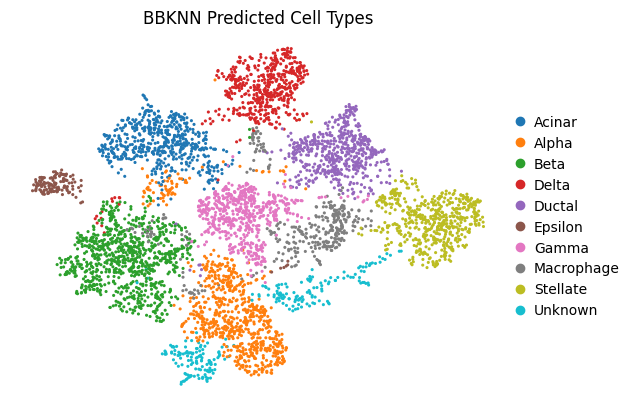


BBKNN - Macro F1: 0.087 | Accuracy: 0.367

                            precision    recall  f1-score   support

                    Acinar       0.26      0.97      0.41       121
                     Alpha       0.37      0.75      0.49       300
                      Beta       0.38      0.94      0.54       300
                     Delta       0.47      0.60      0.53       300
                    Ductal       0.65      0.95      0.77       300
                   Epsilon       0.21      0.05      0.08       109
                     Gamma       0.19      0.72      0.30       114
       Hybrid_Acinar_Alpha       0.00      0.00      0.00        60
        Hybrid_Acinar_Beta       0.00      0.00      0.00        60
       Hybrid_Acinar_Delta       0.00      0.00      0.00        60
      Hybrid_Acinar_Ductal       0.00      0.00      0.00        60
     Hybrid_Acinar_Epsilon       0.00      0.00      0.00        60
       Hybrid_Acinar_Gamma       0.00      0.00      0.00        60
  H

In [82]:
#Label transfer: assign each validation cell the most common reference
cluster_ref_labels_hybrid= {}
for cluster in ad_bbknn_hvg_hybrid.obs['leiden_cluster'].unique():
    mask_cluster_hybrid= ad_bbknn_hvg_hybrid.obs['leiden_cluster'] == cluster
    mask_train_hybrid= ad_bbknn_hvg_hybrid.obs['study'] == 'training'
    #get cell types of training cells that fall in this cluster
    ref_cells_hybrid= ad_bbknn_hvg_hybrid.obs.loc[mask_cluster_hybrid & mask_train_hybrid, 'cell_type']
    #if there are training cells in this cluster, assign the most common cell type
    if len(ref_cells_hybrid) > 0:
        cluster_ref_labels_hybrid[cluster]= ref_cells_hybrid.value_counts().idxmax()
    else:
        cluster_ref_labels_hybrid[cluster] = 'Unknown'

#map cluster labels to predicted cell types for all cells
ad_bbknn_hvg_hybrid.obs['bbknn_predicted'] = (ad_bbknn_hvg_hybrid.obs['leiden_cluster'].map(cluster_ref_labels_hybrid).astype(str))

#visualize the predicted labels on umap
sc.pl.umap(ad_bbknn_hvg_hybrid, color='bbknn_predicted', size=20, frameon=False,
           title='BBKNN Predicted Cell Types', save='_bbknn_predicted.png')

#get the predicted and the true masks of the cells
val_mask_bbknn_hybrid = ad_bbknn_hvg_hybrid.obs['study'] == 'validation'
y_true_bbknn_hybrid = ad_bbknn_hvg_hybrid.obs.loc[val_mask_bbknn_hybrid, 'cell_type']
y_pred_bbknn_hybrid = ad_bbknn_hvg_hybrid.obs.loc[val_mask_bbknn_hybrid, 'bbknn_predicted']

#get the sklearn metrics
bbknn_f1_macro_hybrid = f1_score(y_true_bbknn_hybrid, y_pred_bbknn_hybrid, average='macro', zero_division=0)
bbknn_accuracy_hybrid = accuracy_score(y_true_bbknn_hybrid, y_pred_bbknn_hybrid)
print(f'\nBBKNN - Macro F1: {bbknn_f1_macro_hybrid:.3f} | Accuracy: {bbknn_accuracy_hybrid:.3f}\n')
print(classification_report(y_true_bbknn_hybrid, y_pred_bbknn_hybrid, zero_division=0))

categories: 0, 1, 2, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


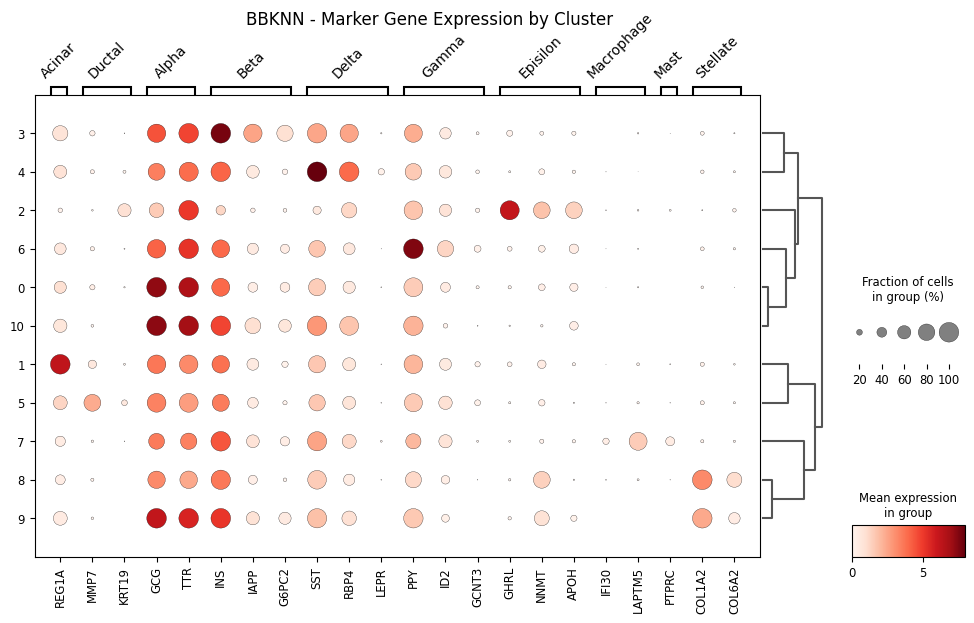

categories: Acinar, Alpha, Beta, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


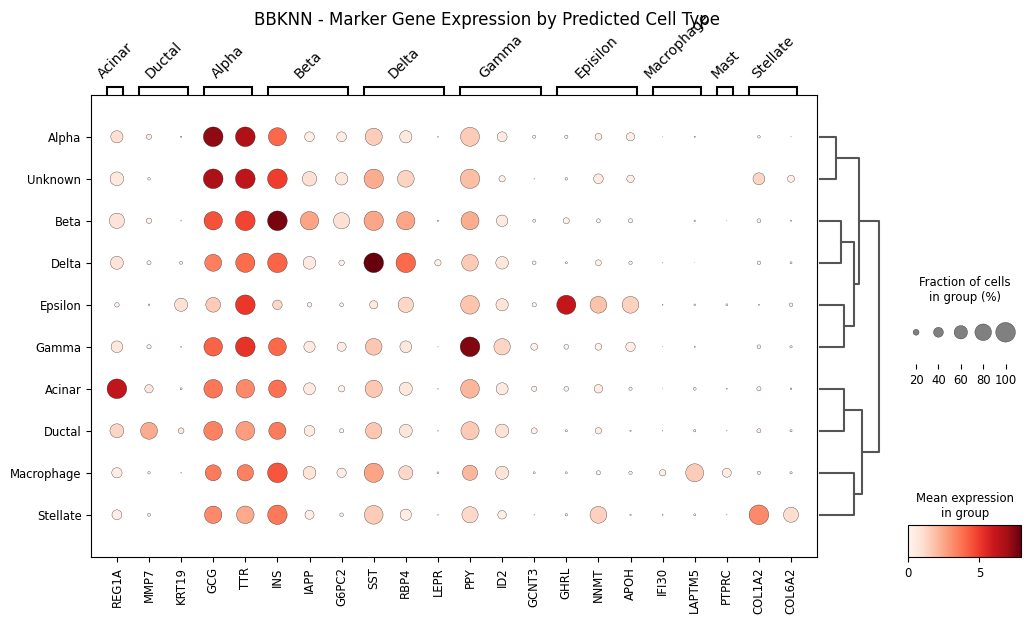

In [71]:
#This follows the same filtering in the pipeline function code
filtered_markers = {}
for cell_type, genes in marker_genes.items():
    present_genes = [g for g in genes if g in ad_bbknn_hvg_hybrid.var_names]
    if present_genes:
        filtered_markers[cell_type] = present_genes

#dotplot to validate cluster identities
sc.pl.dotplot(ad_bbknn_hvg_hybrid, filtered_markers, groupby='leiden_cluster',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='BBKNN - Marker Gene Expression by Cluster\n\n\n')

#dotplot showing predicted cell types vs marker expression
sc.pl.dotplot(ad_bbknn_hvg_hybrid, filtered_markers, groupby='bbknn_predicted',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='BBKNN - Marker Gene Expression by Predicted Cell Type\n\n\n')
plt.show()

In [65]:
#identify hybrids by the Hybrid_ prefix in cell_type
ad_bbknn_hvg_hybrid.obs['is_hybrid'] = ad_bbknn_hvg_hybrid.obs['cell_type'].str.startswith('Hybrid_')
hybrid_mask = ad_bbknn_hvg_hybrid.obs['is_hybrid']

#reconstruct parent1 and parent2 from Hybrid_Parent1_Parent2 format
ad_bbknn_hvg_hybrid.obs['parent1'] = ''
ad_bbknn_hvg_hybrid.obs['parent2'] = ''
ad_bbknn_hvg_hybrid.obs.loc[hybrid_mask, 'parent1'] = (
    ad_bbknn_hvg_hybrid.obs.loc[hybrid_mask, 'cell_type'].str.split('_').str[1])
ad_bbknn_hvg_hybrid.obs.loc[hybrid_mask, 'parent2'] = (
    ad_bbknn_hvg_hybrid.obs.loc[hybrid_mask, 'cell_type'].str.split('_').str[2])

#reconstruct alpha from hybrid_metadata using the obs_name index
#hybrid_metadata index was set as 'hybrid_0', 'hybrid_1', etc
#after concat the hybrid cells have obs_names like 'hybrid-hybrid_0', 'hybrid-hybrid_1'
#strip the 'hybrid-' prefix to recover the original index
ad_bbknn_hvg_hybrid.obs['alpha'] = 0.0

hybrid_obs_names = ad_bbknn_hvg_hybrid.obs.index[hybrid_mask]
#strip the 'hybrid-' prefix added by sc.concat
stripped_names = hybrid_obs_names.str.replace('hybrid-', '', regex=False)

#map alpha values from hybrid_metadata
alpha_series = hybrid_metadata.set_index(hybrid_metadata.index)['alpha']
ad_bbknn_hvg_hybrid.obs.loc[hybrid_mask, 'alpha'] = stripped_names.map(alpha_series).values

In [83]:
val_mask = ad_bbknn_hvg_hybrid.obs['study'] == 'validation'
pure_mask = val_mask & ~hybrid_mask
hybrid_val_mask = val_mask & hybrid_mask

# metrics on pure validation cells
y_true_pure = ad_bbknn_hvg_hybrid.obs.loc[pure_mask, 'cell_type']
y_pred_pure = ad_bbknn_hvg_hybrid.obs.loc[pure_mask, 'bbknn_predicted']
print('\nPure Validation Cells')
print(f'\nBBKNN - Macro F1: {f1_score(y_true_pure, y_pred_pure, average="macro", zero_division=0):.3f} | Accuracy: {accuracy_score(y_true_pure, y_pred_pure):.3f}\n')
print(classification_report(y_true_pure, y_pred_pure, zero_division=0))




Pure Validation Cells

BBKNN - Macro F1: 0.684 | Accuracy: 0.793

              precision    recall  f1-score   support

      Acinar       0.94      0.97      0.96       121
       Alpha       0.69      0.75      0.72       300
        Beta       0.82      0.94      0.87       300
       Delta       0.98      0.60      0.75       300
      Ductal       0.96      0.95      0.95       300
     Epsilon       1.00      0.05      0.09       109
       Gamma       0.51      0.72      0.60       114
  Macrophage       1.00      0.88      0.94        17
    Stellate       1.00      0.94      0.97       300
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.79      1861
   macro avg       0.79      0.68      0.68      1861
weighted avg       0.88      0.79      0.80      1861



In [68]:
#what does the classifier predict for hybrid cells
hybrid_obs = ad_bbknn_hvg_hybrid.obs[hybrid_val_mask][['cell_type', 'parent1', 'parent2', 'alpha', 'bbknn_predicted']].copy()

print('\nHybrid Cell Predictions (top prediction per pair and alpha)')
summary = (hybrid_obs
           .groupby(['parent1', 'parent2', 'alpha'])['bbknn_predicted']
           .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown')
           .reset_index()
           .rename(columns={'bbknn_predicted': 'top_prediction'}))
print(summary.to_string())


Hybrid Cell Predictions (top prediction per pair and alpha)
        parent1     parent2  alpha top_prediction
0        Acinar       Alpha    0.3          Alpha
1        Acinar       Alpha    0.5         Acinar
2        Acinar       Alpha    0.7         Acinar
3        Acinar        Beta    0.3           Beta
4        Acinar        Beta    0.5           Beta
5        Acinar        Beta    0.7         Acinar
6        Acinar       Delta    0.3          Delta
7        Acinar       Delta    0.5          Delta
8        Acinar       Delta    0.7          Delta
9        Acinar      Ductal    0.3         Acinar
10       Acinar      Ductal    0.5         Acinar
11       Acinar      Ductal    0.7         Acinar
12       Acinar     Epsilon    0.3         Acinar
13       Acinar     Epsilon    0.5         Acinar
14       Acinar     Epsilon    0.7         Acinar
15       Acinar       Gamma    0.3         Acinar
16       Acinar       Gamma    0.5         Acinar
17       Acinar       Gamma    0.7     

<a id='scn'></a>
## 3.4 pySingleCellNet Classification

Same code as in question 1

Training classifier |████████████████████████████████████████| 5/5 [100%] in 15.4s (0.32/s) 

Classification thresholds (5% FPR):
                  0
Acinar      0.42460
Alpha       0.61620
Beta        0.42050
Delta       0.47000
Ductal      0.77030
Epsilon     0.81145
Gamma       0.71015
Macrophage  0.69080
Stellate    0.91590


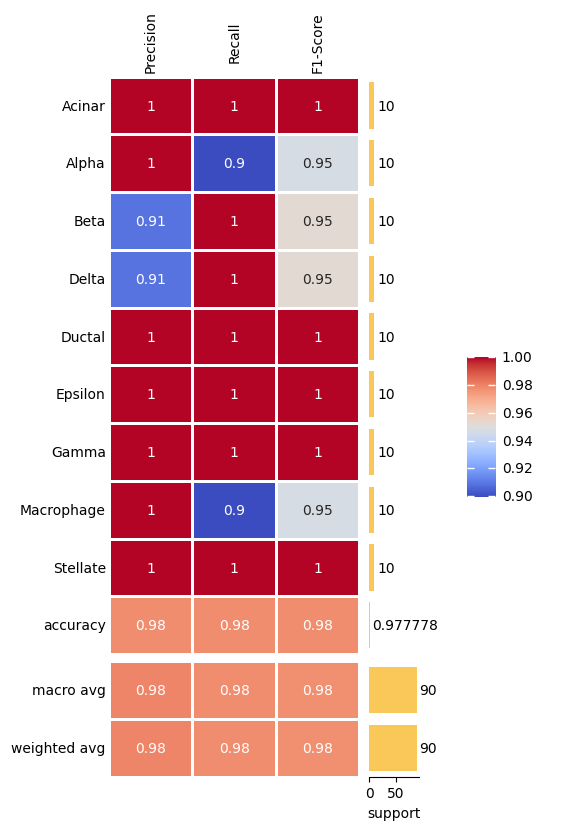

In [70]:
adRef_hybrid= training.copy()
adVal_hybrid= combined_adata.copy()

#limit to common genes in both training and validation
cn.ut.limit_anndata_to_common_genes([adRef_hybrid, adVal_hybrid])

#get indices for training and held-out cells
tids_hybrid, vids_hybrid = cn.ut.split_adata_indices(adRef_hybrid, n_cells, groupby=groupby)

adTrain_scn_hybrid=adRef_hybrid[tids_hybrid].copy()
#internal held-out for calibration
adHO_scn_hybrid= adRef_hybrid[vids_hybrid].copy()


#preprocess training partition (same as what I did in my pipeline function)
sc.pp.highly_variable_genes(adTrain_scn_hybrid, n_top_genes=3000, flavor='seurat_v3')
sc.pp.normalize_total(adTrain_scn_hybrid)
sc.pp.log1p(adTrain_scn_hybrid)

clf_hybrid=cn.tl.train_classifier(adTrain_scn_hybrid, groupby, nRand=n_rand,nTopGenes=nTopGenes, nTopGenePairs=nTopGenePairs, n_comps=n_comps)

#evaluate on internal held-out (to get calibration thresholds)
cn.tl.classify_anndata(adHO_scn_hybrid, clf_hybrid)
c_report_ho_hybrid=cn.tl.create_classifier_report(adHO_scn_hybrid, ground_truth=groupby, prediction='SCN_class_argmax')
cn.pl.heatmap_classifier_report(c_report_ho_hybrid)

#classification thresholds based on held-out set
#determines confidence cutoffs for each cell type at 5% false positive rate
tThrs_hybrid=cn.tl.comp_ct_thresh(adHO_scn_hybrid, 0.05)
print('\nClassification thresholds (5% FPR):')
print(tThrs_hybrid)

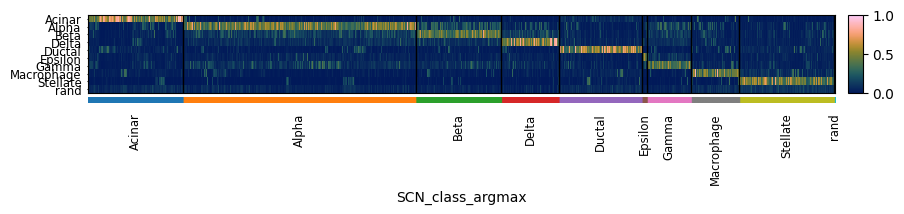

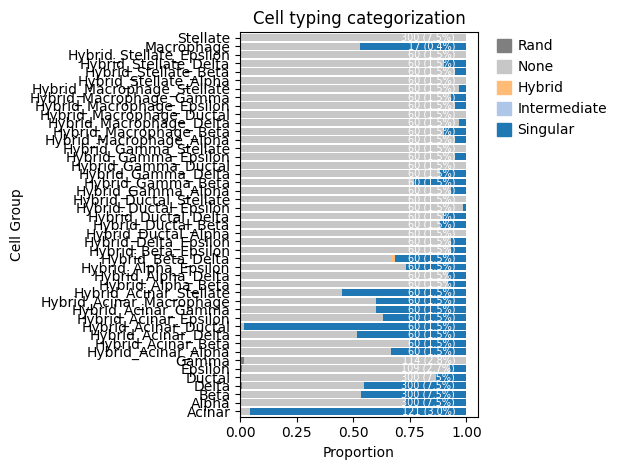


pySCN - Macro F1: 0.088 | Accuracy: 0.371

                            precision    recall  f1-score   support

                    Acinar       0.23      0.98      0.37       121
                     Alpha       0.24      1.00      0.39       300
                      Beta       0.50      0.77      0.61       300
                     Delta       0.58      0.60      0.59       300
                    Ductal       0.63      0.94      0.76       300
                   Epsilon       0.21      0.06      0.09       109
                     Gamma       0.30      0.63      0.41       114
       Hybrid_Acinar_Alpha       0.00      0.00      0.00        60
        Hybrid_Acinar_Beta       0.00      0.00      0.00        60
       Hybrid_Acinar_Delta       0.00      0.00      0.00        60
      Hybrid_Acinar_Ductal       0.00      0.00      0.00        60
     Hybrid_Acinar_Epsilon       0.00      0.00      0.00        60
       Hybrid_Acinar_Gamma       0.00      0.00      0.00        60
  H

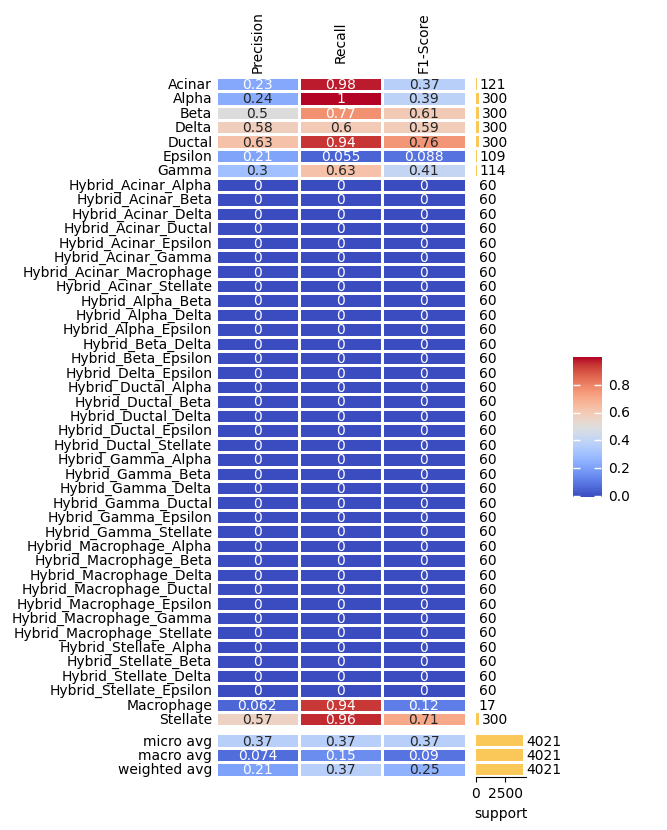

In [75]:
#PAGA-based graph showing relationships between cell types
#used for categorizing uncertain predictions
rela_graph_hybrid=cn.tl.paga_connectivities_to_igraph(adTrain_scn_hybrid, threshold=0.3, n_comps=30, group_key=groupby)

#classify the validation dataset
cn.tl.classify_anndata(adVal_hybrid, clf_hybrid)
cn.tl.categorize_classification(adVal_hybrid, tThrs_hybrid, rela_graph_hybrid)

cn.pl.heatmap_scores(adVal_hybrid, groupby='SCN_class_argmax')
cn.pl.stackedbar_categories(adVal_hybrid, class_col_name='cell_type', show_pct_total=True)
plt.show()

adVal_hybrid.obs[groupby]=adVal_hybrid.obs[groupby].astype('category')
adVal_hybrid.obs['SCN_class_argmax']=adVal_hybrid.obs['SCN_class_argmax'].astype('category')

c_report_val_hybrid = cn.tl.create_classifier_report(adVal_hybrid, ground_truth=groupby, prediction='SCN_class_argmax')
cn.pl.heatmap_classifier_report(c_report_val_hybrid)

#get the sklearn metrics, which is same code as the bbknn and manual
y_true_scn_hybrid=adVal_hybrid.obs['cell_type']
y_pred_scn_hybrid=adVal_hybrid.obs['SCN_class_argmax']
scn_f1_macro_hybrid=f1_score(y_true_scn_hybrid, y_pred_scn_hybrid, average='macro', zero_division=0)
scn_accuracy_hybrid=accuracy_score(y_true_scn_hybrid, y_pred_scn_hybrid)
print(f'\npySCN - Macro F1: {scn_f1_macro_hybrid:.3f} | Accuracy: {scn_accuracy_hybrid:.3f}\n')
print(classification_report(y_true_scn_hybrid, y_pred_scn_hybrid, zero_division=0))

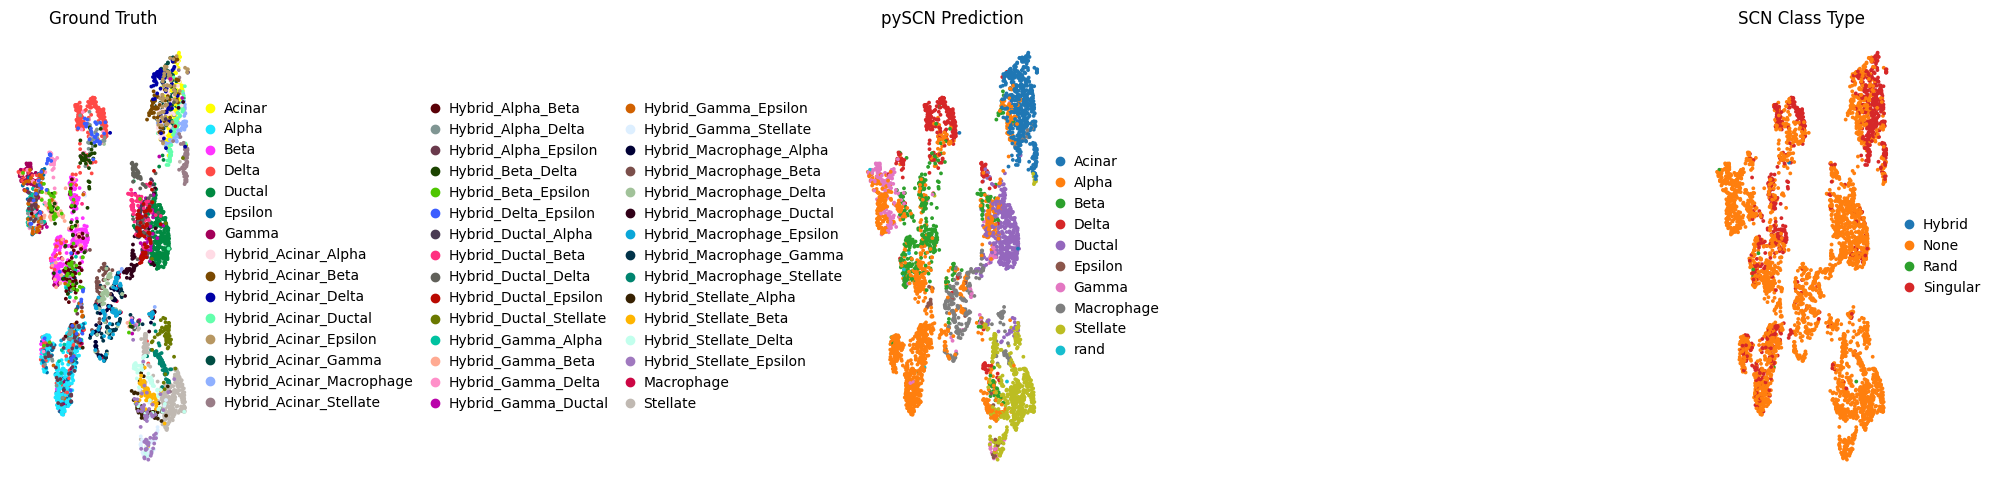

In [76]:
#UMAP of validation with pySCN labels
#follows the same preprocessing steps as before
adVal_viz_hybrid=adVal_hybrid.copy()
adVal_viz_hybrid.layers['counts']=adVal_viz_hybrid.X.copy()
sc.pp.normalize_total(adVal_viz_hybrid)
sc.pp.log1p(adVal_viz_hybrid)
sc.pp.highly_variable_genes(adVal_viz_hybrid, n_top_genes=3000, flavor='seurat_v3', layer='counts')
sc.tl.pca(adVal_viz_hybrid, mask_var='highly_variable')
sc.pp.neighbors(adVal_viz_hybrid, n_neighbors=10, n_pcs=30)
sc.tl.umap(adVal_viz_hybrid)

fig, axes=plt.subplots(1, 3, figsize=(20, 5))
sc.pl.umap(adVal_viz_hybrid, color='cell_type', size=30, frameon=False,
           title='Ground Truth', ax=axes[0], show=False)
sc.pl.umap(adVal_viz_hybrid, color='SCN_class_argmax', size=30, frameon=False,
           title='pySCN Prediction', ax=axes[1], show=False)
sc.pl.umap(adVal_viz_hybrid, color='SCN_class_type', size=30, frameon=False,
           title='SCN Class Type', ax=axes[2], show=False)
plt.tight_layout()
plt.show()

categories: Acinar, Alpha, Beta, etc.
var_group_labels: Acinar, Ductal, Alpha, etc.


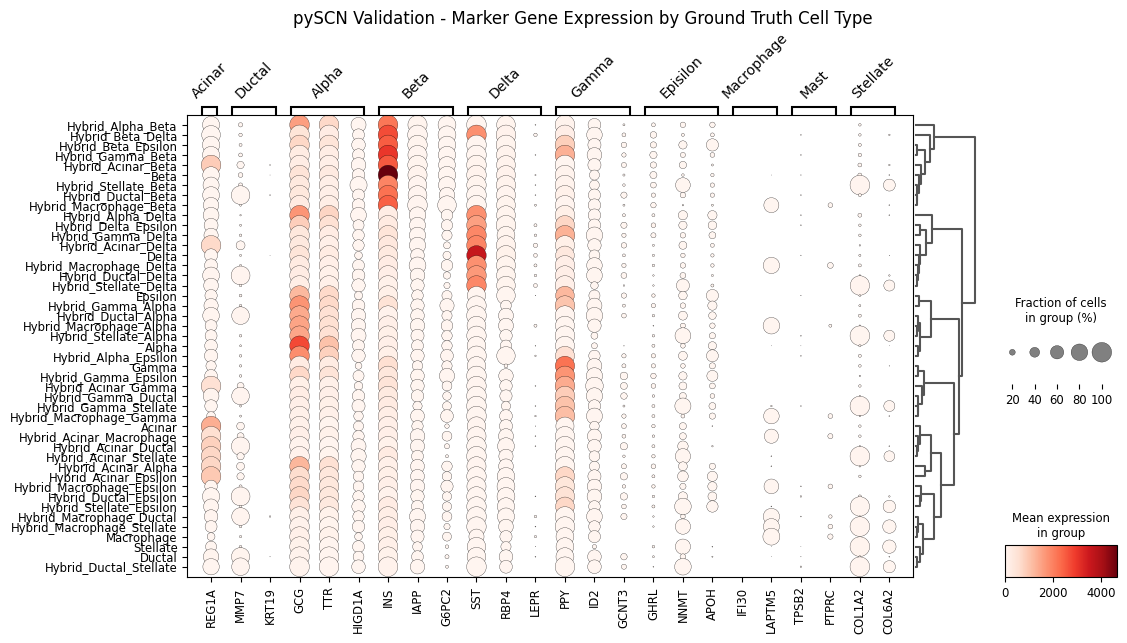

In [77]:
#dotplot for the SCN data
filtered_markers_scn_hybrid = {}
for cell_type, genes in marker_genes.items():
    present_genes_hybrid=[g for g in genes if g in adVal_hybrid.var_names]
    if present_genes_hybrid:
        filtered_markers_scn_hybrid[cell_type]=present_genes_hybrid

sc.pl.dotplot(adVal_hybrid, filtered_markers_scn_hybrid, groupby='cell_type',
              dendrogram=True, var_group_rotation=45, figsize=(12, 6),
              title='pySCN Validation - Marker Gene Expression by Ground Truth Cell Type\n\n\n\n')

In [81]:
hybrid_mask_scn=adVal_hybrid.obs['cell_type'].str.startswith('Hybrid_')

# pure cells only
y_true_pure_scn=adVal_hybrid.obs.loc[~hybrid_mask_scn, 'cell_type']
y_pred_pure_scn=adVal_hybrid.obs.loc[~hybrid_mask_scn, 'SCN_class_argmax']
print('Pure Validation Cells')
print(f'\npySCN - Macro F1: {f1_score(y_true_pure_scn, y_pred_pure_scn, average="macro", zero_division=0):.3f} | Accuracy: {accuracy_score(y_true_pure_scn, y_pred_pure_scn):.3f}\n')
print(classification_report(y_true_pure_scn, y_pred_pure_scn, zero_division=0))

Pure Validation Cells

pySCN - Macro F1: 0.667 | Accuracy: 0.802

              precision    recall  f1-score   support

      Acinar       0.91      0.98      0.94       121
       Alpha       0.55      1.00      0.71       300
        Beta       0.88      0.77      0.82       300
       Delta       0.99      0.60      0.75       300
      Ductal       0.99      0.94      0.97       300
     Epsilon       1.00      0.06      0.10       109
       Gamma       0.55      0.63      0.59       114
  Macrophage       0.73      0.94      0.82        17
    Stellate       0.99      0.96      0.98       300
        rand       0.00      0.00      0.00         0

    accuracy                           0.80      1861
   macro avg       0.76      0.69      0.67      1861
weighted avg       0.87      0.80      0.79      1861



In [79]:
# hybrid cells: what does pySCN predict for each pair and alpha
hybrid_obs_scn=adVal_hybrid.obs[hybrid_mask_scn].copy()
hybrid_obs_scn['parent1'] = hybrid_obs_scn['cell_type'].str.split('_').str[1]
hybrid_obs_scn['parent2']=hybrid_obs_scn['cell_type'].str.split('_').str[2]

print('\nHybrid Cell Top Predictions')
summary=(hybrid_obs_scn
           .groupby(['parent1', 'parent2', 'alpha'])['SCN_class_argmax']
           .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'Unknown')
           .reset_index()
           .rename(columns={'SCN_class_argmax': 'top_prediction'}))
print(summary.to_string())


Hybrid Cell Top Predictions
        parent1     parent2  alpha top_prediction
0        Acinar       Alpha    0.3          Alpha
1        Acinar       Alpha    0.5         Acinar
2        Acinar       Alpha    0.7         Acinar
3        Acinar        Beta    0.3         Acinar
4        Acinar        Beta    0.5         Acinar
5        Acinar        Beta    0.7         Acinar
6        Acinar       Delta    0.3         Acinar
7        Acinar       Delta    0.5         Acinar
8        Acinar       Delta    0.7         Acinar
9        Acinar      Ductal    0.3         Acinar
10       Acinar      Ductal    0.5         Acinar
11       Acinar      Ductal    0.7         Acinar
12       Acinar     Epsilon    0.3         Acinar
13       Acinar     Epsilon    0.5         Acinar
14       Acinar     Epsilon    0.7         Acinar
15       Acinar       Gamma    0.3         Acinar
16       Acinar       Gamma    0.5         Acinar
17       Acinar       Gamma    0.7         Acinar
18       Acinar  Macr

<a id='3result'></a>

## 3.5 Results

### Results of Cell Typing Methods on Hybrid Cell Populations

#### Overall Performance on Hybrid-Containing Datasets

When analyzing populations that include synthetic hybrid cells, all three cell-typing methods show dramatic performance degradation compared to their performance on pure validation cells. The manual annotation method achieves a Macro F1 score of only 0.244 on the full dataset (pure + hybrid cells), compared to 0.349 on pure cells alone, which is a drop of 0.105. BB-KNN fares even worse, with its Macro F1 plummeting from 0.684 on pure cells to just 0.087 on the hybrid-containing dataset, which is a drop of 0.597. pySCN similarly collapses from 0.667 on pure cells to 0.088 on the hybrid dataset, a drop of 0.579. Hybrids between transcriptionally distinct lineages, such as Ductal and Stellate, were detected with high accuracy (F1=0.91), likely because their combined expression profile creates a unique signature that does not closely resemble either parent. In contrast, hybrids between more closely related types, such as Ductal and Epsilon (both epithelial-derived), were completely undetectable (F1=0.00), as their expression profiles presumably fall within the range of variation already present in the parent populations. These dramatic decreases reveal a fundamental limitation: all three methods are optimized to classify cells into discrete, pre-defined categories and fundamentally fail when confronted with intermediate expression states that do not perfectly match any training type. Note that for BB-KNN and pySCN, we are referencing the training dataset, which does not have hybrid labels. IT makes sense why these methods are not able to classify hydrids since that is not in the training dataset.

#### Method-Specific Failure Patterns

Each method exhibits distinct failure patterns when encountering hybrid cells.

Manual annotation, which relies on cluster-based label transfer, shows a strong parental bias. I predominantly assigned hybrid cells to one of the two parent types rather than recognizing them as intermediate. For example, Acinar-Alpha hybrids are almost always classified as Acinar regardless of the mixing ratio, while Acinar-Gamma hybrids are correctly identified as hybrid only at certain ratios (achieving an F1 of 0.67). However, most hybrid types receive F1 scores of 0.00, meaning the method completely fails to recognize them as distinct populations. The top predictions table reveals that manual annotation defaults to the more abundant or transcriptionally dominant parent type, effectively erasing hybrid identity. I also had only 20 clusters when I had around 36 hybrid cell types, which led to many of the hybrids to be clustered within a larger cluster. I could have changed my resolution of my leiden clustering to something bigger to help identify the hybrids better. Even with a higher resolution however, the fundamental limitation of manual annotation would still be there. The intermediate expression profiles produce ambiguous dotplots where marker gene signal from both parents is present but diluted, and a human annotator relying on binary marker logic would still tend to call one parent or the other based on whichever signature appears stronger. The method's reliance on discrete marker genes makes it structurally unable to represent transitional states. I found that the most difficult hybrid to identify are endocrine-endocrine hybrids due to them being transcriptionally similar.

BBKNN shows an even more extreme pattern of binary switching. When examining the top predictions for hybrid cells, BBKNN nearly always assigns hybrids to one parent type or the other, with a sharp transition at alpha=0.5. For instance, Acinar-Beta hybrids are classified as Beta at alpha=0.3 and 0.5, but switch to Acinar at alpha=0.7. This creates an artificial dichotomy where continuously varying expression profiles are forced into discrete categories. Notably, BBKNN achieves reasonable performance on pure cells (Macro F1 0.684) but completely fails on hybrids with every single hybrid cell type receives an F1 of 0.00, meaning the method detects no hybrid populations whatsoever. The few hybrid types that appear in the predictions (like Hybrid_Macrophage_Ductal with F1 0.90 in manual annotation) are completely absent in BBKNN's results. Additionally, BBKNN produces Unknown predictions for several Stellate-containing hybrid pairs at low alpha values, which is a failure mode not seen in the other two methods. This occurs because Stellate cells form a transcriptionally distinct cluster, and hybrids that dilute the Stellate signature sufficiently fall into a neighborhood that does not map cleanly to any training cluster, resulting in no confident label assignment other than a wrong one.

pySCN exhibits the most nuanced but still inadequate behavior. Like the other methods, it fails to recognize most hybrid types (F1 scores of 0.00 for nearly all hybrid categories). However, the top predictions table reveals that pySCN sometimes makes more biologically plausible errors. For example, classifying Beta-Epsilon hybrids as Alpha, which is a related endocrine cell type, rather than defaulting to one parent. This suggests pySCN's classifier is attempting to find the closest match in transcriptional space, even when that match is neither parent. However, this does not translate into better metrics, as the method still cannot correctly identify hybrid cells as a distinct category A notable pattern in pySCN's predictions is a strong bias toward Alpha across many hybrid combinations involving endocrine cell types Alpha-Beta, Alpha-Delta, Gamma-Alpha, Delta-Epsilon, and Gamma-Epsilon hybrids are all predominantly called Alpha regardless of alpha level. This suggests pySCN's random forest features the Alpha signature heavily, likely because Alpha cells are the most numerous class in the training data with 300 cells and a distinctive GCG expression profile, causing the classifier to default toward Alpha when a hybrid's expression does not cleanly match a single type. While BBKNN achieved slightly higher Macro F1 on pure cells (0.684 vs 0.667 for pySCN), pySCN's more nuanced error patterns and its ability to provide classification uncertainty metrics make it better suited for detecting potential transcriptional shifts in transplanted cells.

### Impact of the Analysis of Real Engineered Cells

These findings have profound implications for the analysis of real engineered cell populations. Engineered cells, like reprogrammed iPSCs, often exist in hybrid states that these methods fail to detect. They may co-express markers from multiple lineages, exhibit partial reprogramming, or display novel transcriptional programs that do not match any reference cell type.

The failure modes observed suggest that:

Engineered cells would likely misclassified as one of their parent types, leading researchers to mistakenly conclude that engineering was more successful (or less successful) than it actually was. For example, a partially reprogrammed cell might be classified as the original cell type (if it retains enough of that signature) or as the target cell type (if it expresses enough target markers), when in reality it exists in a beneficial intermediate state. If a researcher engineers a Beta cell by partially reprogramming an Acinar cell, all three methods would likely report a confident call of either Acinar or Beta depending on which transcriptional signature dominate, which gives no indication that the cell is transitional or incompletely converted. A researcher could interpret a confident Beta classification as evidence of successful reprogramming when the cell is actually a 70/30 hybrid retaining substantial Acinar identity.

Novel hybrid phenotypes would be completely invisible to BBKNN and nearly invisible to manual annotation and pySCN, as evidenced by the 0.00 F1 scores for most hybrid categories. This means that successful engineering creating truly novel cell states would go undetected, with these cells simply absorbed into existing categories.

The uncertain classification mechanism in pySCN (which could flag potentially interesting cells) appears insufficient. The method still forces most cells into existing categories rather than labeling them as uncertain or novel.

Rare engineered populations would be particularly vulnerable to misclassification. The analysis shows that even abundant hybrid populations (60 cells per type) are missed, suggesting that small populations of successfully engineered cells would be completely lost in the noise.

#### Recommendations for Engineered Cell Analysis

We should probably not rely on any single cell typing method. Instead, we should use multiple methods and look for consensus and disagreement. We should pay special attention to cells that receive low-confidence predictions or are classified differently across methods, as these may represent truly intermediate or novel states. The results suggest that standard single-cell classification methods should be interpreted with caution in engineering contexts, and that complementary approaches such as trajectory analysis, multi-label classification, or continuous scoring against multiple reference types may be necessary to reliably characterize cells with mixed or intermediate identities We need to develop custom classifiers that include engineered cell examples in the training set if any are available, rather than relying solely on reference atlases of healthy cells.s. The current gap in the research is that all these methods are designed to categorize cells into discrete, pre-defined types and fundamentally cannot represent the continuous, intermediate, or novel states that are the very goal of many cell engineering efforts.

<a id='question-4'></a>
# 4. How does transplantation affect engineered pancreatic-like cells?

### pySCN Pipeline for Query Dataset Classification

1. Prepare data for classifier training
   - Create copies of training and query datasets
   - Restrict both datasets to common genes to ensure feature compatibility
   - Training data contains reference cell types
   - query data contains transplanted and non-transplanted cells

2. Train pySCN classifier
   - Followed the same pipeline as in problem 1
   - Apply trained classifier to all query cells to get prediction scores and assign to highest score

3. Analyze transplantation effects
   - Compare cell type proportions between Transplant and Stage6 conditions
   - Assess classification uncertainty rates by condition
   - Perform differential expression analysis for each cell type (Transplant vs Stage6)
   - Identify top 10 differentially expressed genes per cell type
   - Conduct pathway enrichment analysis on DE genes
   - Find shared dysregulated genes across multiple cell types

<a id='scn4'></a>
## 4.1  Cell-type predictions of the query data using pySCN

Follows the same code from problem 1

In [92]:
print(query.obs['condition'].value_counts())
print(query.obs['sample_name'].value_counts())

condition
Stage6        2000
Transplant    2000
Name: count, dtype: int64
sample_name
ESSt6      2000
ES3txp      790
ES1txp      460
IPS1txp     431
ES2txp      319
Name: count, dtype: int64


Training classifier |████████████████████████████████████████| 5/5 [100%] in 16.1s (0.31/s) 

Classification thresholds (5% FPR):
                  0
Acinar      0.69650
Alpha       0.54190
Beta        0.44270
Delta       0.47470
Ductal      0.62920
Epsilon     0.69775
Gamma       0.58775
Macrophage  0.54220
Stellate    0.96005


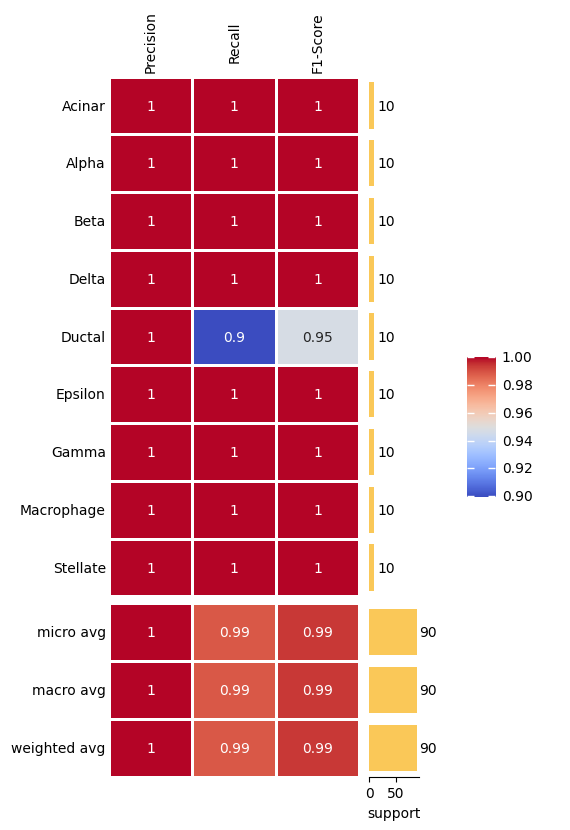

In [104]:
adRef_query=training.copy()
adVal_query = query.copy()

#limit to common genes in both training and validation
cn.ut.limit_anndata_to_common_genes([adRef_query, adVal_query])

#get indices for training and held-out cells
tids_q, vids_q=cn.ut.split_adata_indices(adRef_query, n_cells, groupby=groupby)

adTrain_q=adRef_query[tids_q].copy()
#internal held-out for calibration
adHO_q= adRef_query[vids_q].copy()


#preprocess training partition (same as what I did in my pipeline function)
sc.pp.highly_variable_genes(adTrain_q, n_top_genes=3000, flavor='seurat_v3')
sc.pp.normalize_total(adTrain_q)
sc.pp.log1p(adTrain_q)

clf_q=cn.tl.train_classifier(adTrain_q, groupby, nRand=n_rand,nTopGenes=nTopGenes, nTopGenePairs=nTopGenePairs, n_comps=n_comps)


#evaluate on internal held-out (to get calibration thresholds)
cn.tl.classify_anndata(adHO_q, clf_q)
c_report_ho_q=cn.tl.create_classifier_report(adHO_q, ground_truth=groupby, prediction='SCN_class_argmax')
cn.pl.heatmap_classifier_report(c_report_ho_q)

#classification thresholds based on held-out set
#determines confidence cutoffs for each cell type at 5% false positive rate
tThrs_q=cn.tl.comp_ct_thresh(adHO_q, 0.05)
print('\nClassification thresholds (5% FPR):')
print(tThrs_q)


In [105]:
#PAGA-based graph showing relationships between cell types
#used for categorizing uncertain predictions
rela_graph_q=cn.tl.paga_connectivities_to_igraph(
    adTrain_q, threshold=0.3, n_comps=30, group_key=groupby)

# classify and categorize query data
cn.tl.classify_anndata(adVal_query, clf_q)
cn.tl.categorize_classification(adVal_query, tThrs_q, rela_graph_q)

print(adVal_query.obs['SCN_class_argmax'].value_counts())
print(adVal_query.obs['SCN_class_cat'].value_counts())

SCN_class_argmax
Alpha         2281
Beta           635
rand           395
Ductal         255
Gamma          238
Stellate        94
Acinar          53
Epsilon         32
Delta           16
Macrophage       1
Name: count, dtype: int64
SCN_class_cat
None      2510
Alpha      707
Rand       395
Beta       270
Ductal      77
Acinar      41
Name: count, dtype: int64


<a id='prop'></a>
## 4.2  Cell Type Proportions Stage6 vs Transplant


Cell type proportions:
condition         Stage6  Transplant
SCN_class_argmax                    
Acinar             0.000       0.026
Alpha              0.922       0.218
Beta               0.006       0.311
Delta              0.002       0.006
Ductal             0.000       0.127
Epsilon            0.000       0.016
Gamma              0.014       0.106
Macrophage         0.000       0.000
Stellate           0.000       0.047
rand               0.056       0.142


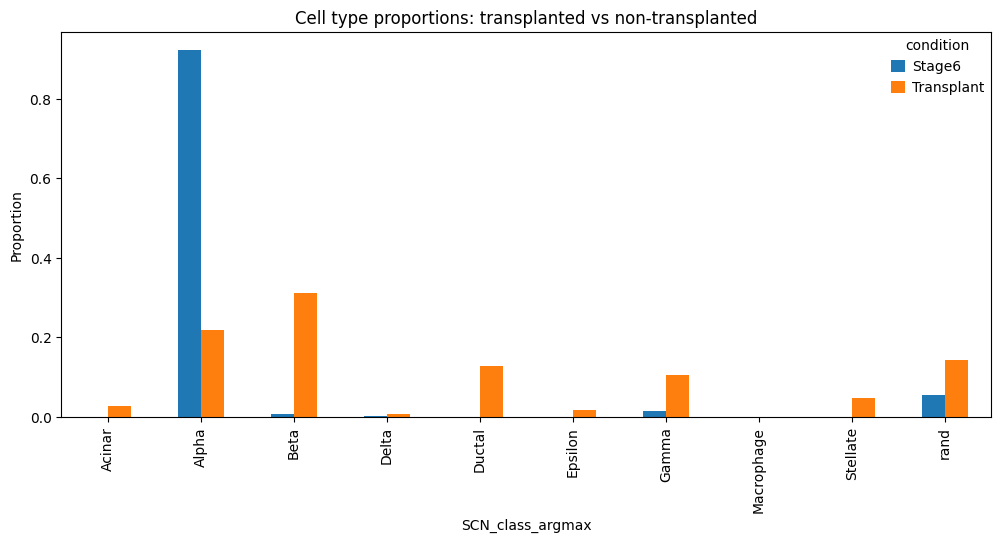


Chi-squared test: chi2=2109.71, p=0.0000, dof=9
Differences are statistically significant


In [117]:
prop_table = (adVal_query.obs.groupby(['condition', 'SCN_class_argmax']).size().unstack(fill_value=0))

#normalize to proportions within each condition
prop_norm= prop_table.div(prop_table.sum(axis=1), axis=0)

print('\nCell type proportions:')
print(prop_norm.T.round(3))

#stacked bar plot
prop_norm.T.plot(kind='bar', figsize=(12, 5))
plt.ylabel('Proportion')
plt.title('Cell type proportions: transplanted vs non-transplanted')
plt.legend(title='condition')
plt.show()

#chi-squared test to check if differences are statistically significant or could reflect sampling variation
chi2, p, dof, expected=chi2_contingency(prop_table)
print(f'\nChi-squared test: chi2={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Differences are statistically significant' if p < 0.05
      else 'Differences could reflect sampling variation (p >= 0.05)')

<a id='uncert'></a>
## 4.3  Proportion of Uncertain Identity Cells

is_uncertain   False   True 
condition                   
Stage6        0.9445  0.0555
Transplant    0.8580  0.1420

Proportion uncertain by condition:
is_uncertain   False   True 
condition                   
Stage6        0.9445  0.0555
Transplant    0.8580  0.1420


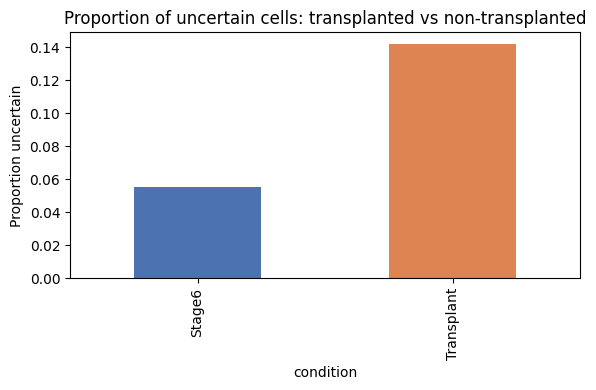


Transplanted cells show 8.6% higher uncertainty rate


In [140]:
#treat rand and None predictions as uncertain
adVal_query.obs['is_uncertain']=adVal_query.obs['SCN_class_type'].isin(['Unknown', 'Rand'])

print(adVal_query.obs.groupby('condition')['is_uncertain'].value_counts(normalize=True).unstack().fillna(0))

uncertain_by_condition=(adVal_query.obs.groupby('condition')['is_uncertain'].value_counts(normalize=True).unstack().fillna(0))

print('\nProportion uncertain by condition:')
print(uncertain_by_condition)

uncertain_by_condition[True].plot(kind='bar', figsize=(6, 4), color=['#4C72B0', '#DD8452'])
plt.ylabel('Proportion uncertain')
plt.title('Proportion of uncertain cells: transplanted vs non-transplanted')
plt.tight_layout()
plt.show()

print(f'\nTransplanted cells show {(uncertain_by_condition[True]['Transplant'] - uncertain_by_condition[True]['Stage6'])*100:.1f}% higher uncertainty rate')

<a id='dge'></a>
## 4.4 Differential Gene Expression per Cell Type

Skipping Ductal: insufficient cells ({'Transplant': 254, 'Stage6': 1})

Top 10 DE genes for Beta (Transplant vs Stage6):
  names  logfoldchanges  pvals_adj
  FXYD2        4.990692   0.001876
   ASB9        3.544293   0.001876
  G6PC2        4.095132   0.001876
  TTC36       30.108603   0.004679
   SCG5        1.446971   0.004886
PPP1R1A        1.510323   0.005373
  RAMP1        3.548273   0.005373
 IGFBP7        3.606822   0.009044
 PDLIM2       29.735983   0.009469
   HOPX        1.781957   0.012056

Top 10 DE genes for Alpha (Transplant vs Stage6):
  names  logfoldchanges     pvals_adj
   FOSB        5.132571 2.268673e-124
   CHGB        2.145208 3.210571e-117
CAMK2N1        1.618128  1.688861e-98
    JUN        3.105071  3.197220e-88
  HLA-A        2.198201  1.286421e-86
   JUND        1.468019  2.552044e-84
  ZFP36        4.082861  2.035646e-82
 EEF1A1        0.774797  1.709908e-81
  NR4A1        3.276364  6.940695e-73
  TTC36        6.042430  2.153514e-70

Top 10 DE genes for Gamm

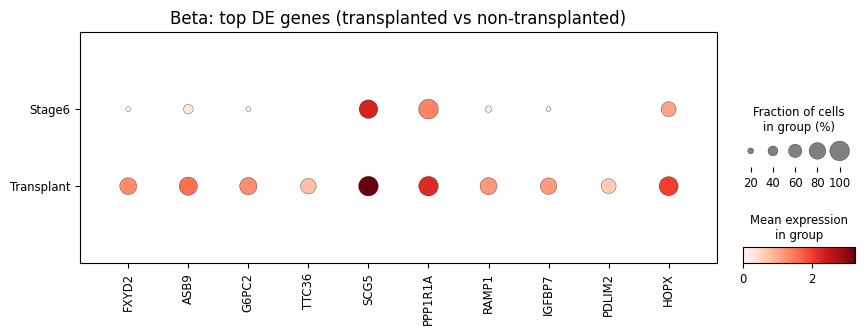

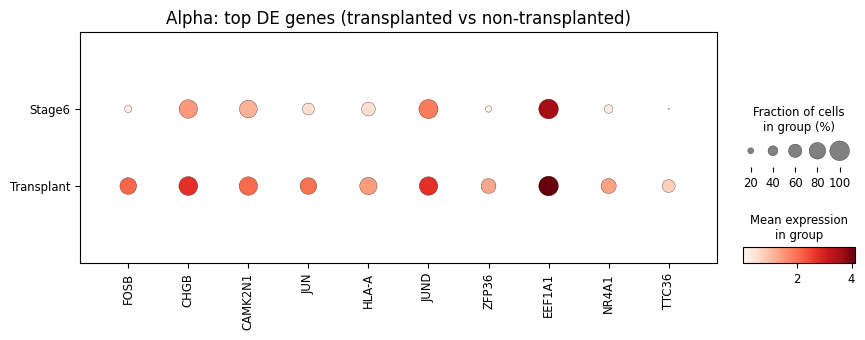

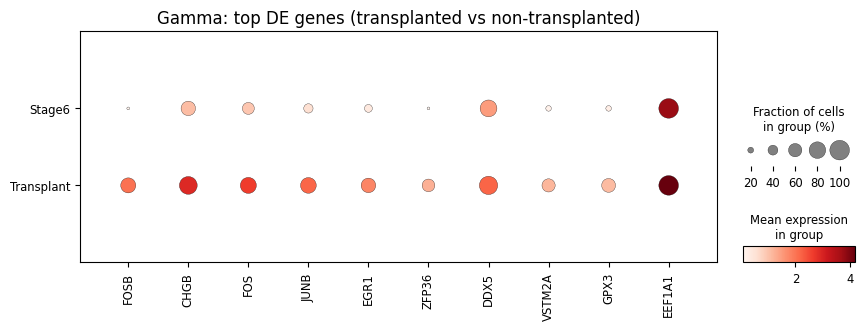

In [139]:
adVal_query.obs['SCN_class_argmax'] = adVal_query.obs['SCN_class_argmax'].astype(str)
adVal_query.obs['condition']=adVal_query.obs['condition'].astype(str)

cell_types=[ct for ct in adVal_query.obs['SCN_class_argmax'].unique()
              if ct != 'rand']

dge_results= {}

for ct in cell_types:
    mask=adVal_query.obs['SCN_class_argmax'] == ct
    sub=adVal_query[mask].copy()

    condition_counts=sub.obs['condition'].value_counts()
    if len(condition_counts)<2 or condition_counts.min() < 5:
        print(f'Skipping {ct}: insufficient cells ({condition_counts.to_dict()})')
        continue

    sc.pp.normalize_total(sub, target_sum=1e4)
    sc.pp.log1p(sub)
    sc.tl.rank_genes_groups(sub, groupby='condition',
                             groups=['Transplant'],
                             reference='Stage6',
                             method='wilcoxon',
                             key_added='dge_transplant')

    top10=sc.get.rank_genes_groups_df(sub, group='Transplant', key='dge_transplant').head(10)

    dge_results[ct]={'adata': sub, 'top10': top10}

    print(f'\nTop 10 DE genes for {ct} (Transplant vs Stage6):')
    print(top10[['names', 'logfoldchanges', 'pvals_adj']].to_string(index=False))

# dotplot per cell type showing top 10 genes split by condition
for ct, res in dge_results.items():
    sub=res['adata']
    top_genes=res['top10']['names'].tolist()

    sc.pl.dotplot(sub, var_names=top_genes, groupby='condition',
                  title=f'{ct}: top DE genes (transplanted vs non-transplanted)',
                  figsize=(10, 3), show=True)

<a id='enrich'></a>
## 4.5 Enrichment Analysis per Cell Type Using Gseapy

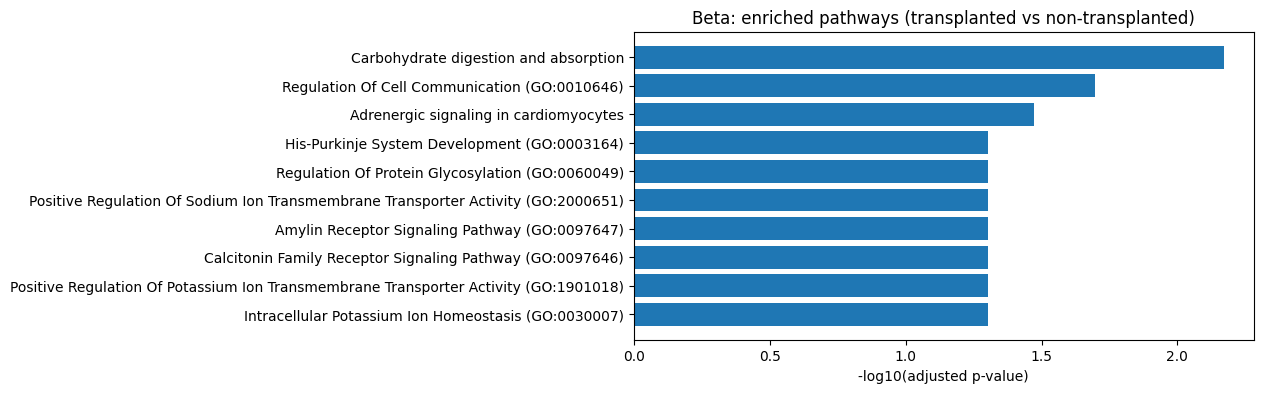

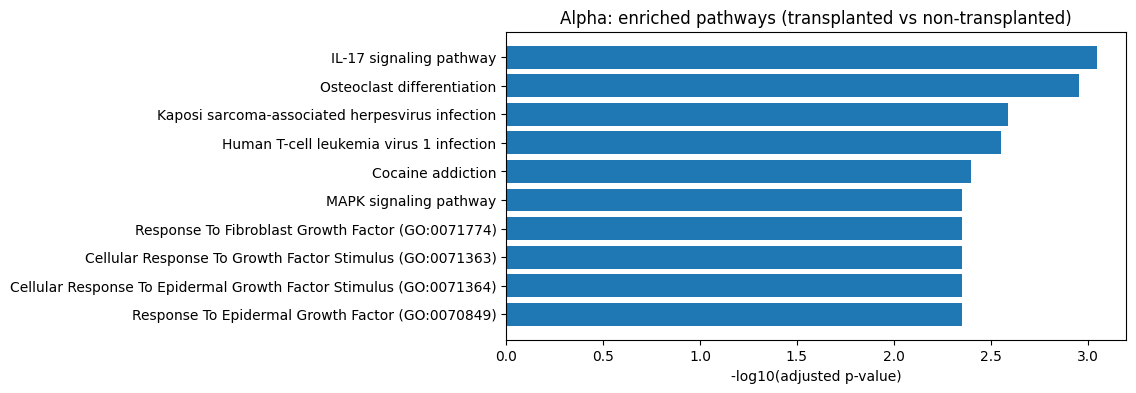

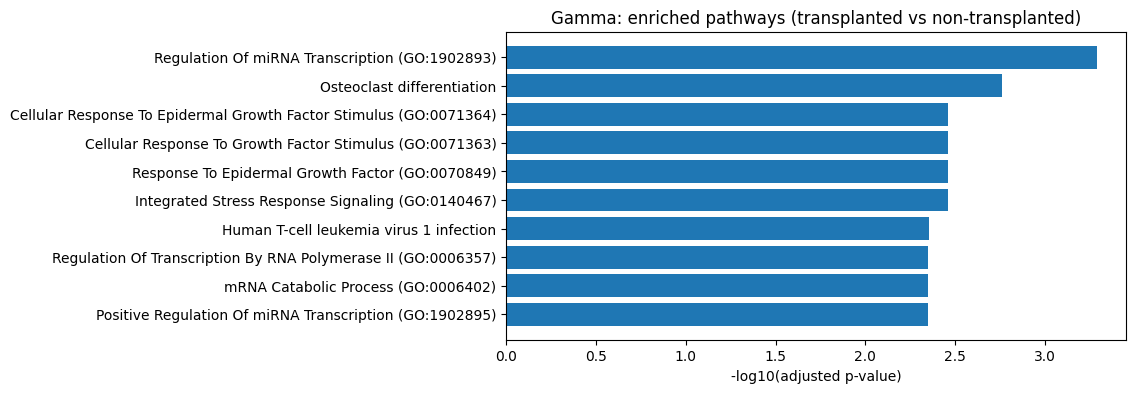

In [124]:
enrichment_results={}

for ct, res in dge_results.items():
    top_genes=res['top10']['names'].tolist()

    #run enrichment against GO biological process
    enr=gp.enrichr(gene_list=top_genes,
                     gene_sets=['GO_Biological_Process_2023',
                                'KEGG_2021_Human'],
                     organism='human',
                     outdir=None,
                     verbose=False)

    enrichment_results[ct]=enr.results

    #plot top 10 enriched terms
    top_terms=enr.results.sort_values('Adjusted P-value').head(10)

    fig, ax=plt.subplots(figsize=(8, 4))
    ax.barh(top_terms['Term'][::-1], -np.log10(top_terms['Adjusted P-value'][::-1]))
    ax.set_xlabel('-log10(adjusted p-value)')
    ax.set_title(f'{ct}: enriched pathways (transplanted vs non-transplanted)')
    plt.show()

<a id='dysre'></a>
## 4.6 Shared Dysregulated Genes Across All Cell Types


Genes dysregulated in multiple cell types:
  TTC36: found in 2 cell types - ['Beta', 'Alpha']
  CHGB: found in 2 cell types - ['Alpha', 'Gamma']
  EEF1A1: found in 2 cell types - ['Alpha', 'Gamma']
  ZFP36: found in 2 cell types - ['Alpha', 'Gamma']
  FOSB: found in 2 cell types - ['Alpha', 'Gamma']


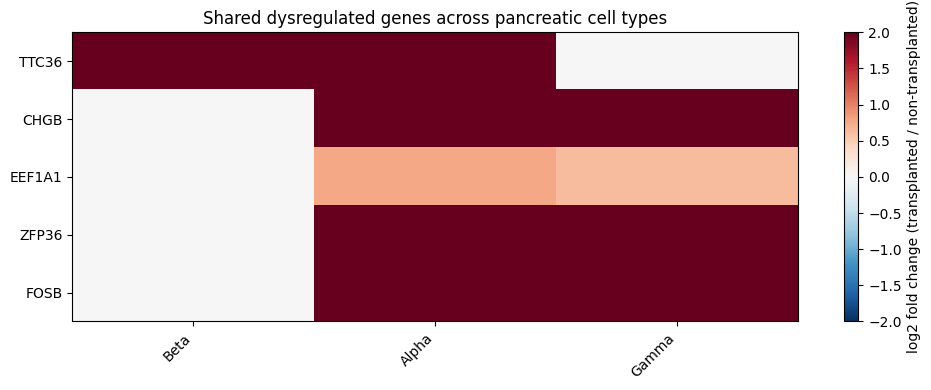

In [126]:
#collect all top 10 gene lists
all_gene_lists= {ct: set(res['top10']['names'].tolist()) for ct, res in dge_results.items()}

#find genes appearing in multiple cell types
all_genes_flat = [gene for genes in all_gene_lists.values() for gene in genes]
gene_counts=Counter(all_genes_flat)
shared_genes={gene: count for gene, count in gene_counts.items() if count > 1}
shared_genes_sorted=dict(sorted(shared_genes.items(), key=lambda x: x[1], reverse=True))

print('\nGenes dysregulated in multiple cell types:')
for gene, count in shared_genes_sorted.items():
    cell_types_with_gene=[ct for ct, genes in all_gene_lists.items()
                             if gene in genes]
    print(f'  {gene}: found in {count} cell types - {cell_types_with_gene}')

lfc_matrix=pd.DataFrame(index=list(shared_genes_sorted.keys()), columns=list(dge_results.keys()))

for ct, res in dge_results.items():
    df=res['top10'].set_index('names')
    for gene in lfc_matrix.index:
        if gene in df.index:
            lfc_matrix.loc[gene, ct]=df.loc[gene, 'logfoldchanges']

lfc_matrix= lfc_matrix.astype(float).fillna(0)

fig, ax=plt.subplots(figsize=(10, max(4, len(lfc_matrix) * 0.5)))
im=ax.imshow(lfc_matrix.values, cmap='RdBu_r', aspect='auto',
               vmin=-2, vmax=2)
ax.set_xticks(range(len(lfc_matrix.columns)))
ax.set_xticklabels(lfc_matrix.columns, rotation=45, ha='right')
ax.set_yticks(range(len(lfc_matrix.index)))
ax.set_yticklabels(lfc_matrix.index)
plt.colorbar(im, ax=ax, label='log2 fold change (transplanted / non-transplanted)')
ax.set_title('Shared dysregulated genes across pancreatic cell types')
plt.tight_layout()
plt.show()

<a id='4results'></a>
## 4.7 Results

### Effect of Transplantation on Engineered Pancreatic-Like Cells


####  Proportion of cells of uncertain identity increases with transplantation
Transplantation increases the proportion of cells with uncertain identity, though the effect is modest. Before transplantation, 5.6% of Stage6 cells fall below the confidence threshold, while after transplantation this rises to 14.2, which is an 8.6 percentage point increase. This suggests that the transplant environment pushes some cells into transcriptional states that do not map cleanly onto the reference cell types the classifier was trained on, which may reflect genuine biological changes rather than technical noise.

#### Proportions differ between conditions
The cell type proportions shift dramatically between Stage6 and Transplant conditions, and these differences are highly statistically significant (chi-squared=2109.71, p-value is approximately 0). Before transplantation, the population is dominated almost entirely by Alpha cells (92.2%), with minimal Beta (0.6%) and Gamma (1.4%) representation. After transplantation, Alpha drops to 21.8% while Beta rises to 31.1%, Ductal emerges at 12.7%, Gamma increases to 10.6%, and several cell types including Stellate, Acinar, Epsilon, and Macrophage appear exclusively in the transplant condition. These shifts are almost certainly a mix of real biology and technical factors. The emergence of non-endocrine cell types like Stellate, Ductal, and Macrophage exclusively after transplantation likely reflects infiltration of host-derived cells into the graft rather than the differentiation of the engineered cells themselves. The large increase of Beta cells relative to Alpha is biologically plausible. Maybe the transplant environment may provide signals that promote Beta cell maturation or survival, but since the Stage6 population has very few Beta cells to begin with, some of this shift could also reflect sampling variation or classifier behavior in a new expression context.

#### Differential expression analysis
Differential gene expression analysis was performed for the three cell types with sufficient cells in both conditions,  Alpha, Beta, and Gamma, using a Wilcoxon rank-sum test comparing Transplant against Stage6 as the reference. Note: there was not enough cells (>2) in the Delta cells in Stage6 to do differntial genes expression, and any of the cell types were missing in the dataset.

In Alpha cells, the top differentially expressed genes include FOSB, JUN, JUND, ZFP36, and NR4A1, all of which are immediate early response genes and transcription factors associated with cellular stress, MAPK signaling, and rapid transcriptional activation in response to extracellular stimuli (I asked ChatGPT what these markers do since there were a lot of them). The statistical confidence of these results is remarkably high, with p-values reaching as low as 2.3e-124, indicating a consistent and strong transcriptional response across the Alpha cell population. Enrichment analysis for Alpha confirms activation of the MAPK signaling pathway, IL-17 signaling, growth factor response pathways including EGF and FGF, and osteoclast differentiation (osteoclast is an unexpected result. might be from shared transcription factor usage rather than a true bone cell program).


In Beta cells, the top DE genes include FXYD2, G6PC2, TTC36, RAMP1, and IGFBP7, which are more functionally specific to Beta cell identity and insulin secretion (again, I asked ChatGPT what these genes did). The enrichment results for Beta cells show activation of carbohydrate digestion and absorption, amylin and calcitonin receptor signaling, and ion transport regulation, suggesting that transplanted Beta cells are more functionally mature than their Stage6 counterparts.


Gamma cells show a DE profile that overlaps substantially with Alpha, including FOSB, CHGB, ZFP36, FOS, JUNB, and EGR1, pointing to a shared stress or activation response across the endocrine compartment. Their enrichment results similarly feature growth factor response terms and integrated stress response signaling, consistent with the idea that transplantation imposes a common environmental pressure on all endocrine cell types.


#### Shared dysregulated genes
Five genes are commonly dysregulated across multiple cell types: FOSB and ZFP36 are upregulated in both Alpha and Gamma, CHGB and EEF1A1 are shared between Alpha and Gamma, and TTC36 appears in both Beta and Alpha. The heatmap of shared genes shows that all five are strongly upregulated in transplanted cells relative to Stage6 (all log2 fold changes are positive and saturate the upper end of the color scale, except for EEF1A1 which has slightly lower FC), with no genes showing downregulation in the transplant condition. FOSB and ZFP36 are immediate early genes that are rapidly induced by mechanical stress, immune signaling, and growth factor exposure. The shared upregulation across Alpha and Gamma suggests a pan-endocrine response to the transplant microenvironment rather than a cell-type-specific program. CHGB encodes chromogranin B, a secretory protein found in dense core vesicles of endocrine cells, and its upregulation may reflect increased secretory activity after engraftment. EEF1A1 encodes a translation elongation factor and its upregulation is consistent with increased protein synthesis demand in a metabolically active post-transplant state. TTC36, which appears in both Beta and Alpha with extremely high fold changes (30 and 6 respectively), might mean that these cells are actively promoting c-Myc stability and accumulation and c-Myc drives proliferation and growth.


In summary, transplantation induces three coordinated responses in engineered pancreatic cells:

1. a pan-endocrine stress response (FOSB/JUN/ZFP36 upregulation) shared across Alpha and Gamma cells
2. Beta cell maturation evidenced by upregulation of insulin secretion machinery
3. host infiltration introducing non-endocrine populations

Sources:

Antonescu, C. R., Chen, H. W., Zhang, L., Sung, Y. S., Panicek, D., Agaram, N. P., Dickson, B. C., Krausz, T., & Fletcher, C. D. (2014). ZFP36-FOSB fusion defines a subset of epithelioid hemangioma with atypical features. Genes, chromosomes & cancer, 53(11), 951–959. https://doi.org/10.1002/gcc.22206


Zhang, K., Biswas, N., Gayen, J. R., Miramontes-Gonzalez, J. P., Hightower, C. M., Mustapic, M., Mahata, M., Huang, C. T., Hook, V. Y., Mahata, S. K., Vaingankar, S., & O'Connor, D. T. (2014). Chromogranin B: intra- and extra-cellular mechanisms to regulate catecholamine storage and release, in catecholaminergic cells and organisms. Journal of neurochemistry, 129(1), 48–59. https://doi.org/10.1111/jnc.12527

Vera, M., Pani, B., Griffiths, L. A., Muchardt, C., Abbott, C. M., Singer, R. H., & Nudler, E. (2014). The translation elongation factor eEF1A1 couples transcription to translation during heat shock response. eLife, 3, e03164. https://doi.org/10.7554/eLife.03164


Shao, F., Wang, R., Li, X. et al. TTC36 promotes proliferation and drug resistance in hepatocellular carcinoma cells by inhibiting c-Myc degradation. Cell Death Dis 16, 332 (2025). https://doi.org/10.1038/s41419-025-07663-4



<a id='question-5'></a>
# 5. Hybrid Identity Score

### Hybrid Identity Score Pipeline for pySCN Classification Results

1. Extract classification scores
   - Access the score matrix stored in `adata.obsm[score_key]` (default: 'SCN_score')
   - Convert to pandas DataFrame with cell names as index
   - Each column represents a cell type, each value is the classification confidence score


2. Filter out excluded labels
   - Remove placeholder/excluded labels (default: rand) from consideration
   - These represent uncertain/unassigned cells and shouldn't count as valid cell types. This ensures hybrid scoring only considers true cell type identities

3. Identify top-scoring cell type
   - Find maximum score for each cell, which is stored as top1_score (confidence value)
   - Identify corresponding cell type label, which is stored as top1_celltype (primary prediction)

4. Identify second-highest scoring cell type
   - Create masked copy of score matrix
   - mask out top1 label by setting its score to negative infinity for each cell
   - Find maximum of remaining scores, which is stored as top2_score (secondary confidence value)
   - Identify corresponding cell type label, which is store as top2_celltype(secondary prediction)

5. hybrid identity score
   - Compute ratio: `hybrid_score=top2_score / top1_score`
   - Score interpretation:
     - Near 0: Strong, unambiguous identity (top1 much higher than top2)
     - Near 1: Ambiguous/hybrid identity (top1 and top2 have similar confidence)

6. Create hybrid pair labels
   - Sort the top1 and top2 cell type names alphabetically
   - Join with underscore to create consistent pair identifier
   - Example: For cells with top1=A'lpha', top2='Beta' → 'Alpha_Beta'
   - Example: For cells with top1='Beta', top2='Alpha' → 'Alpha_Beta' (same)
   - This ensures bidirectional hybrids are grouped together
   - Store as `hybrid_pair` in `adata.obs`


In [143]:
def hybrid_identity_score(adata, score_key='SCN_score', exclude_labels=['rand']):

    #extract score matrix as a dataframe with cell type names as columns
    score_matrix=pd.DataFrame(adata.obsm[score_key], index=adata.obs_names)

    #drop excluded labels from scoring so rand doesn't count as a cell type
    cols_to_use = [c for c in score_matrix.columns if c not in exclude_labels]
    score_matrix= score_matrix[cols_to_use]

    #get top1 and top2 scores and their corresponding cell type labels
    top1_scores=score_matrix.max(axis=1)
    top1_labels=score_matrix.idxmax(axis=1)

    #mask out top1 to find top2
    score_matrix_masked=score_matrix.copy()
    for idx in score_matrix_masked.index:
        score_matrix_masked.loc[idx, top1_labels[idx]]=-np.inf

    top2_scores=score_matrix_masked.max(axis=1)
    top2_labels=score_matrix_masked.idxmax(axis=1)

    #hybrid score=top2/top1
    #clip top1 at a small value to avoid division by zero
    hybrid_score=top2_scores/top1_scores.clip(lower=1e-6)

    adata.obs['hybrid_score']=hybrid_score.values
    adata.obs['top1_celltype']=top1_labels.values
    adata.obs['top2_celltype']=top2_labels.values
    adata.obs['top1_score']= top1_scores.values
    adata.obs['top2_score']= top2_scores.values

    #sorted pair label
    adata.obs['hybrid_pair']=['_'.join(sorted([t1, t2])) for t1, t2 in zip(top1_labels, top2_labels)]

    return adata

We want to compare validation (normal pancreatic cells), query, and the synthetic hybrid datasets. We know that query Stage6 is the engineered pre-transplant, and query Transplant is the engineered post-transplant.  The combined_adata contains the synthetic hybrids. We want to classify validation with the query classifier so scores are comparable.

In [145]:
adVal_query = hybrid_identity_score(adVal_query)

#use the same classifier clf_q that was trained for the query analysis
cn.tl.classify_anndata(validation, clf_q)
validation_scored=hybrid_identity_score(validation)

#apply to combined_adata which has both real and synthetic hybrid cells
cn.tl.classify_anndata(combined_adata, clf_q)
combined_scored=hybrid_identity_score(combined_adata)

The Mann-Whitney U test (rank-sum) was used because hybrid scores are bounded between 0 and 1 and will likely be heavily skewed, meaning that most cells will cluster near 0 (pure identity) with a long tail toward 1. A t-test assumes normality, which this data will violate. We want to know whether engineered cells tend to have higher hybrid scores than normal cells, which is a statement about the entire distribution, not just the average (t-test compares means). The rank-sum test asks 'does one group tend to rank higher than the other'. Using `alternative='less'` tests specifically whether normal cells tend to score lower than engineered cells.

Mean hybrid identity scores by context:
  Normal validation (pure pancreatic):  0.39172976930990616
  Stage6 (engineered pre-transplant):   0.38330997536053185
  Transplant (engineered post-transplant): 0.48547780907333654
  Synthetic hybrids:                    0.6018240413199668

Mann-Whitney U: normal vs Stage6 - U=1824228, p=1.4402e-01
Mann-Whitney U: normal vs Transplant - U=1474256, p=2.7243e-29
Mann-Whitney U: normal vs Synthetic - U=1068334, p=2.0393e-145
Mann-Whitney U: Stage6 vs Transplant - U=1544504, p=5.2610e-36


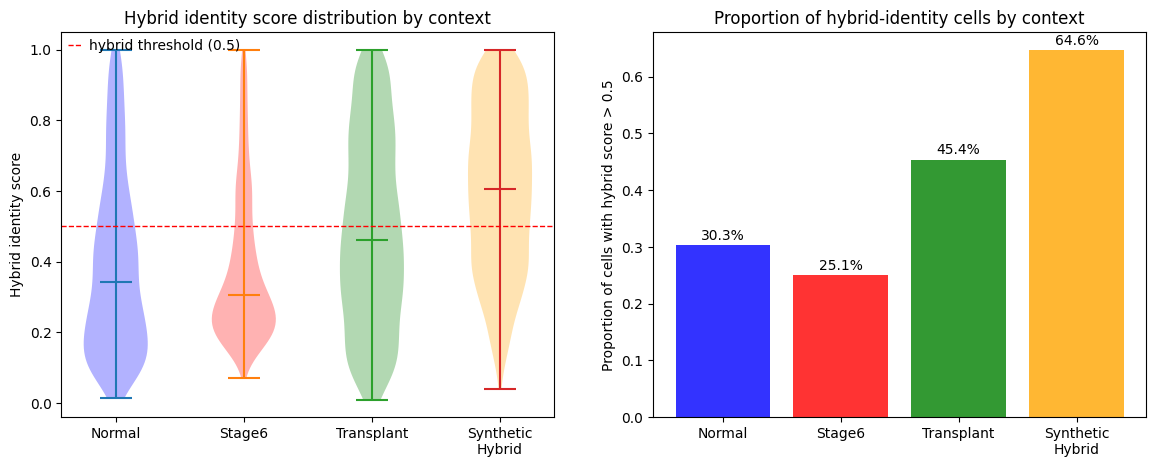

In [153]:
#split query into Stage6 and Transplant
stage6_scores = adVal_query.obs[adVal_query.obs['condition'] == 'Stage6']['hybrid_score']
transplant_scores=adVal_query.obs[adVal_query.obs['condition'] == 'Transplant']['hybrid_score']

#split combined_adata into real and synthetic hybrid cells
real_scores=combined_scored.obs[~combined_scored.obs['is_hybrid']]['hybrid_score']
synthetic_scores=combined_scored.obs[combined_scored.obs['is_hybrid']]['hybrid_score']

#validation is normal pancreatic cells
normal_scores=validation_scored.obs['hybrid_score']

print('Mean hybrid identity scores by context:')
print(f'  Normal validation (pure pancreatic):  {normal_scores.mean()}')
print(f'  Stage6 (engineered pre-transplant):   {stage6_scores.mean()}')
print(f'  Transplant (engineered post-transplant): {transplant_scores.mean()}')
print(f'  Synthetic hybrids:                    {synthetic_scores.mean()}')

#statistical test: are engineered cells more hybrid than normal?
stat, p=mannwhitneyu(normal_scores, stage6_scores, alternative='less')
print(f'\nMann-Whitney U: normal vs Stage6 - U={stat:.0f}, p={p:.4e}')
stat, p=mannwhitneyu(normal_scores, transplant_scores, alternative='less')
print(f'Mann-Whitney U: normal vs Transplant - U={stat:.0f}, p={p:.4e}')
stat, p=mannwhitneyu(normal_scores, synthetic_scores, alternative='less')
print(f'Mann-Whitney U: normal vs Synthetic - U={stat:.0f}, p={p:.4e}')
stat, p=mannwhitneyu(stage6_scores, transplant_scores, alternative='less')
print(f'Mann-Whitney U: Stage6 vs Transplant - U={stat:.0f}, p={p:.4e}')


fig, axes=plt.subplots(1, 2, figsize=(14, 5))
#violin plot comparing hybrid scores across all four contexts
score_df=pd.DataFrame({'hybrid_score': pd.concat([normal_scores,
                                                    stage6_scores,
                                                    transplant_scores,
                                                    synthetic_scores]),
                        'context': (['Normal'] * len(normal_scores) +
                                    ['Stage6'] * len(stage6_scores) +
                                    ['Transplant'] * len(transplant_scores) +
                                    ['Synthetic\nHybrid'] * len(synthetic_scores))})

context_order=['Normal', 'Stage6', 'Transplant', 'Synthetic\nHybrid']
colors=['blue', 'red', 'green', 'orange']

for i, (ctx, color) in enumerate(zip(context_order, colors)):
    data=score_df[score_df['context'] == ctx]['hybrid_score']
    parts=axes[0].violinplot(data, positions=[i], showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)

axes[0].set_xticks(range(len(context_order)))
axes[0].set_xticklabels(context_order)
axes[0].set_ylabel('Hybrid identity score')
axes[0].set_title('Hybrid identity score distribution by context')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='hybrid threshold (0.5)')
axes[0].legend()

# proportion of cells above threshold 0.5 (considered hybrid) per context
threshold=0.5
pct_hybrid=score_df.groupby('context')['hybrid_score'].apply(lambda x: (x > threshold).mean()).reindex(context_order)

axes[1].bar(context_order, pct_hybrid.values, color=colors, alpha=0.8)
axes[1].set_ylabel('Proportion of cells with hybrid score > 0.5')
axes[1].set_title('Proportion of hybrid-identity cells by context')
for i, v in enumerate(pct_hybrid.values):
    axes[1].text(i, v+0.01, f'{v:.1%}', ha='center', fontsize=10)
plt.show()

We can see clearly form the violin and the bar plot that transplanted and the synthetic hybrid has more hybrid cell types than the normal. We see that in the transplant that about half of the distribution is above the 0.5 threshold and about 2/3 of the data in the synthetic are above the threshold. This makes sense as we have 1861 original cells and 2160 hybrid cells in the synthetic data. That means that we have 54% known hybrids in the synthetic data. We might have some more due to annotation differences in the original dataset.

In [162]:
# for each predicted cell type, compare hybrid score in normal vs engineered
print('\nMean hybrid score per cell type:')
print('Cell Type        Normal    Stage6    Transplant\n')

shared_types=set(validation_scored.obs['SCN_class_argmax']) & set(adVal_query.obs['SCN_class_argmax'])

for ct in sorted(shared_types):
    if ct in 'rand':
        continue
    norm_ct=validation_scored.obs[
        validation_scored.obs['SCN_class_argmax'] == ct]['hybrid_score'].mean()
    s6_ct=adVal_query.obs[
        (adVal_query.obs['SCN_class_argmax'] == ct) &
        (adVal_query.obs['condition'] == 'Stage6')]['hybrid_score'].mean()
    tx_ct=adVal_query.obs[
        (adVal_query.obs['SCN_class_argmax'] == ct) &
        (adVal_query.obs['condition'] == 'Transplant')]['hybrid_score'].mean()
    print(f'{ct:<16} {norm_ct:.3f}     {s6_ct:.3f}       {tx_ct:.3f}')


Mean hybrid score per cell type:
Cell Type        Normal    Stage6    Transplant

Acinar           0.236     nan       0.084
Alpha            0.477     0.354       0.478
Beta             0.558     0.817       0.517
Delta            0.460     0.929       0.843
Ductal           0.251     0.522       0.209
Epsilon          0.415     nan       0.644
Gamma            0.612     0.864       0.668
Macrophage       0.268     nan       0.442
Stellate         0.168     nan       0.246


1. Normal cells show baseline hybrid scores:
    - Lowest hybrid scores: Stellate (0.168), Acinar (0.236), Ductal (0.251), Macrophage (0.268)
      - These cell types have strong, unambiguous identities in normal conditions, meaning that their transcriptional programs are distinct and well-defined
    - Highest hybrid scores: Gamma (0.612), Beta (0.558), Alpha (0.477)
      - Endocrine cells (Alpha, Beta, Gamma, Delta) naturally have more ambiguous identities
      - This makes biological sense as they're closely related islet cells sharing common developmental origins
      - Gamma cells showing the highest hybrid score (0.612) suggests they may be very plastic

2. Stage6 (non-transplanted):
    - Delta cells dramatically increase from 0.460 to 0.929 (nearly doubled)
      - Suggests Delta cells become highly ambiguous/plastic at Stage6
      - Could indicate dedifferentiation or activation of alternative programs
    - Beta cells increase from 0.558 to 0.817
    - Gamma cells increase** from 0.612 to 0.864
    - Alpha cells decrease slightly 0.477 to 0.354
      - Alpha cells become more defined, not less
    - Acinar, Epsilon, Macrophage, Stellate missing from Stage6
    - These cell types may be:
      - Too rare to detect
      - Not present in that condition
      - Failed to be classified confidently


3. Transplanted cells show context-dependent effects:
    - Delta cells remain high (0.843) but slightly lower than Stage6
      - Transplantation doesn't rescue Delta cell ambiguity
    - Beta cells return to near-normal (0.517 vs 0.558)
      - Transplantation may help Beta cells "find their identity" again
    - Alpha cells return to normal (0.478 vs 0.477)
    - Epsilon cells increase in transplant (0.644) where they were absent in Stage6. Transplantation may activate or recruit this rare population
    - Macrophage and Stellate appear only in transplant. Maybe these stromal/immune cellsinfiltrate upon transplantation.